# SC3021 Airbnb NYC Pricing Analysis

---

## Environment Setup & Data Loading

In [1]:
!pip install thefuzz python-Levenshtein scikit-learn xgboost

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 5.1 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 4.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 4.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 4.3 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 3.8 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 3.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 3.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#All relevant imports for the notebook
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from scipy import stats
from thefuzz import process
import geopandas as gpd
import seaborn as sns

In [3]:
# SQLite database setup for data management
import sqlite3
from pathlib import Path

db_path = Path('src') / 'airbnb_analysis.db'
sqlite_conn = sqlite3.connect(str(db_path))

print(f'Connected to database at {db_path}')

# Helper function to load data from database
def load_from_db(query):
    return pd.read_sql(query, sqlite_conn)

# Verify database tables
cursor = sqlite_conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print(f'Available tables: {[t[0] for t in tables]}')

# ── External schema: create SQL VIEWs (three-schema architecture) ──────
# Views restrict columns exposed to the analysis layer, push filters to SQL,
# and hide PII/sensitive demographics (SC3021 external schema principle).
views_ddl = [
    "DROP VIEW IF EXISTS v_airbnb",
    """CREATE VIEW v_airbnb AS
       SELECT neighbourhood_group, neighbourhood, latitude, longitude,
              room_type, price, minimum_nights, number_of_reviews,
              reviews_per_month, calculated_host_listings_count, availability_365
       FROM raw_ab_nyc_2019""",
    "DROP VIEW IF EXISTS v_shooting",
    """CREATE VIEW v_shooting AS
       SELECT INCIDENT_KEY, OCCUR_DATE, BORO, Latitude, Longitude
       FROM raw_shooting
       WHERE CAST(substr(OCCUR_DATE, 7, 4) AS INTEGER) BETWEEN 2015 AND 2019""",
    "DROP VIEW IF EXISTS v_arrests",
    """CREATE VIEW v_arrests AS
       SELECT ARREST_DATE, Latitude, Longitude
       FROM raw_arrests
       WHERE CAST(substr(ARREST_DATE, 7, 4) AS INTEGER) BETWEEN 2015 AND 2019
         AND Latitude IS NOT NULL AND Longitude IS NOT NULL
         AND Latitude != 0.0 AND Longitude != 0.0""",
    "DROP VIEW IF EXISTS v_trees",
    """CREATE VIEW v_trees AS
       SELECT nta, nta_name, boroname, latitude, longitude
       FROM raw_trees
       WHERE status = 'Alive'""",
]
for ddl in views_ddl:
    cursor.execute(ddl)
sqlite_conn.commit()
print("Views created: v_airbnb, v_shooting, v_arrests, v_trees")


Connected to database at src\airbnb_analysis.db
Available tables: ['raw_ab_nyc_2019', 'raw_tree_species', 'raw_airbnb', 'raw_shooting', 'raw_trees', 'raw_population', 'raw_nta_population', 'raw_income', 'raw_arrests', 'raw_income_processed', 'dm_precinct', 'sqlite_sequence', 'dm_tree_species_demo', 'dm_tree_demo']
Views created: v_airbnb, v_shooting, v_arrests, v_trees


### Data Management Architecture: Three-Schema Design

This project applies the **ANSI/SPARC three-schema architecture** taught in SC3021 to organise data access across three distinct layers:

| Layer | SC3021 Definition | Implementation |
|---|---|---|
| **Internal schema** | Physical storage of data on disk | SQLite file `src/airbnb_analysis.db` |
| **Conceptual schema** | Full logical structure of the database | Raw tables: `raw_airbnb`, `raw_shooting`, `raw_arrests`, `raw_trees`, `raw_population`, `raw_nta_population`, `raw_income_processed` |
| **External schema** | Application-specific restricted view of the conceptual schema | SQL VIEWs: `v_airbnb`, `v_shooting`, `v_arrests`, `v_trees` |

#### Justification for Each View

**`v_airbnb`** — restricts `raw_airbnb` (16 columns → 11 columns)
- **Dropped:** `id`, `name` (listing title), `host_id`, `host_name`, `last_review`
- `host_id` and `host_name` are personally identifiable information (PII) not required for neighbourhood-level aggregation. The external view enforces that the analysis layer never accesses host identity data, consistent with the lecture's principle that external schemas provide **access control** over the conceptual schema.
- `name` is unstructured free text with no analytical role — retaining it would violate the lecture's "design based on application need" principle.
- `last_review` is unused across all downstream cells; including it would introduce unnecessary **redundancy** at the schema level.

**`v_shooting`** — restricts `raw_shooting` (19 columns → 5 columns) and pushes a temporal filter to SQL
- **Dropped:** `PERP_AGE_GROUP`, `PERP_SEX`, `PERP_RACE`, `VIC_AGE_GROUP`, `VIC_SEX`, `VIC_RACE`, `STATISTICAL_MURDER_FLAG`, `PRECINCT`, `JURISDICTION_CODE`, `LOCATION_DESC`, `X_COORD_CD`, `Y_COORD_CD`, `Lon_Lat`
- Perpetrator and victim demographic attributes contain sensitive racial data that is irrelevant to neighbourhood-level incident-count analysis. The external view restricts these columns from the analysis layer entirely.
- `X_COORD_CD`, `Y_COORD_CD`, and `Lon_Lat` are **redundant** with `Latitude`/`Longitude` — retaining them violates the lecture's schema design principle of avoiding redundancy.
- `WHERE CAST(substr(OCCUR_DATE, 7, 4) AS INTEGER) BETWEEN 2015 AND 2019` pushes temporal filtering to the database engine, eliminating the need to load all rows and filter in Python.

**`v_arrests`** — restricts `raw_arrests` (19 columns → 3 columns) and pushes temporal + coordinate filters to SQL
- **Dropped:** `AGE_GROUP`, `PERP_SEX`, `PERP_RACE`, legal codes (`PD_CD`, `KY_CD`, `LAW_CODE`, `LAW_CAT_CD`), `ARREST_PRECINCT`, `JURISDICTION_CODE`, `OFNS_DESC`, `X_COORD_CD`, `Y_COORD_CD`
- `raw_arrests` contains 5 million rows. Only `ARREST_DATE`, `Latitude`, and `Longitude` are consumed by the analysis. Reducing 19 columns to 3 at the SQL level drastically cuts memory usage.
- Demographic attributes (`AGE_GROUP`, `PERP_SEX`, `PERP_RACE`) are sensitive and not needed for spatial aggregation — the view enforces **access control** by design.
- Coordinate validation (`Latitude IS NOT NULL AND Latitude != 0.0`) is pushed to SQL to remove bad records before they enter the pipeline.
- This demonstrates **logical data independence**: if `raw_arrests` gains new columns, the view and all downstream analysis code remain unchanged.

**`v_trees`** — restricts `raw_trees` (41 columns → 5 columns) and pushes a status filter to SQL
- **Dropped:** 36 unused columns including species taxonomy (`spc_latin`, `spc_common`), stump data, administrative district codes (`st_assem`, `st_senate`, `boro_ct`), and address fields.
- `WHERE status = 'Alive'` removes stumps and dead trees at query time, so only analytically relevant records enter the in-memory dataframe.
- Dropping 36 unused columns aligns with the lecture's **"design based on application need"** principle — the external schema exposes only what is necessary for the analysis task.


In [4]:

# Use project-relative paths (works when cwd is project root; /src/ fails on Windows)
SRC = Path("src")
def _path(name):
    p = SRC / name
    if not p.exists() and "Arrests" in name and " (1)" not in name:
        alt = SRC / "NYPD_Arrests_Data__Historic_ (1).csv"
        return str(alt) if alt.exists() else str(p)
    return str(p)

airbnb_nyc_df = load_from_db("SELECT * FROM v_airbnb")
airbnb_nyc_df['reviews_per_month'] = airbnb_nyc_df['reviews_per_month'].fillna(0)  # listings with no reviews have an implicit rate of 0
nypd_shooting_df = load_from_db("SELECT * FROM v_shooting")  # 2015-2019 temporal filter applied in view
ny_tree_census_df = load_from_db("SELECT * FROM v_trees")  # status='Alive' filter applied in view
total_population_df = load_from_db("SELECT * FROM raw_population")
# Row 4 in the DB table holds the actual column headers (rows 0-3 are metadata)
total_population_df.columns = total_population_df.iloc[4]
total_population_df = total_population_df[5:].reset_index(drop=True)
total_population_df = total_population_df.rename(columns={
    'Location': 'Borough',
    'TimeFrame': 'Year',
    'Data': 'Population'
})
total_population_df['Year'] = pd.to_numeric(total_population_df['Year'], errors='coerce')
total_population_df['Population'] = pd.to_numeric(total_population_df['Population'], errors='coerce')
total_population_df = total_population_df.dropna(subset=['Year', 'Population'])
arrest_data_df = load_from_db("SELECT * FROM v_arrests")  # 2015-2019 + valid-coords filter applied in view
nta_pop_df = load_from_db("SELECT * FROM raw_nta_population")
nyc_gdf = gpd.read_file(_path("nycgeo.json"))
# display(ny_tree_census_df.head())
# display(nypd_shooting_df.head())
# display(airbnb_nyc_df.head())
# display(total_population_df.head())

# **Most Impactful Factors Affecting Airbnb Pricing in New York City**

## Hypothesis/analysis goal (Ask)

## Research Question & Hypothesis

**Most impactful factors affecting Airbnb pricing in New York City**

## Stakeholders

| Stakeholder | Decision / Use Case |
|---|---|
| **New Airbnb hosts** | Set competitive pricing strategy based on neighbourhood features (crime, greenery, income) |
| **Urban planners & policymakers** | Justify zoning decisions and green space investments by showing price impact |
| **Guests / consumers** | Understand neighbourhood quality signals (safety, amenity) reflected in pricing |
| **Existing hosts** | Optimize revenue by identifying underpriced or overpriced neighbourhoods relative to features |

## Mechanistic Hypothesis

Airbnb nightly prices are shaped by neighbourhood-level features that signal desirability and safety to guests, affecting both demand and host competition. **Expected mechanisms**: Median household income acts as a proxy for resident purchasing power and neighbourhood amenity density (restaurants, services), increasing willingness-to-pay for nearby listings. Crime rates (shooting and arrest density) reduce perceived safety and guest confidence, lowering demand and prices. Tree density and green space signal neighbourhood quality and environmental amenity, attracting guests and raising prices. Distance to Central Business District (CBD) affects access to tourist attractions and those employed hence,closer listings command higher prices. Finally, review count and sentiment reduce booking uncertainty for guests, allowing hosts to sustain higher prices through reputation.

These factors combine through a demandâ€“competition channel: when a neighbourhood scores high on safety, greenery, income, and CBD proximity, guests demand listings there, allowing hosts to raise prices; conversely, weak signals on these dimensions reduce guest demand and pressure prices downward. **Note**: This analysis is associative (correlations and predictive patterns), not causal proof. Unobserved confounders (e.g., listing condition, host reputation, marketing effort) may co-vary with neighbourhood features.

**Hypothesis: Greenery, Reviews, Median Income, Distance to CBD and Crime Rate affect Airbnb prices**

As Airbnb grows in popularity across the world, getting an accurate estimate of the price of Airbnbs will help new Airbnb owners to better price their houses. We will explore the relationship between various factors of the Airbnb and its price. We believe that crime rate, greenery around the borough, median income of residents, proximity to the business district and the reviews of the Airbnb will have the greatest impact on its price.

---

## Data source identification and exploration (Prepare)

This section identifies and explores the raw data sources used throughout the analysis.

## Data Sources Overview

**Requirement analysis**: In order to estimate the price of Airbnbs, we have extracted various data points such as room type, number of reviews, availability, boroughs, along with the three factors in our hypothesis. We have selected five other datasets based on New York City.

List of datasets:
- [New York City Airbnb Open Data (2019) ](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)
- [NYPD Arrest Data (2006-2019) ](https://www.kaggle.com/datasets/thaddeussegura/nypd-arrest-data-20062019)
- [New York City Shooting Incident Dataset](https://www.kaggle.com/datasets/thaddeussegura/new-york-city-shooting-dataset)
- [Tree Census in New York City](https://www.kaggle.com/datasets/nycparks/tree-census)
- [Total Population in New York City](https://data.cccnewyork.org/data/map/97/total-population#97/a/3/147/132/a/a)
- [Median Incomes](https://data.cccnewyork.org/data/map/66/median-incomes#66/39/3/107/131/a/a)

**Database schema design:** All datasets are ingested into a SQLite DBMS (`src/airbnb_analysis.db`) and accessed through SQL VIEWs that form the external schema of a three-layer architecture (internal → conceptual → external). This provides logical data independence, column-level access control, and pushes temporal and spatial filters to the database engine rather than Python.

## Dataset Descriptions

### DS1: New York City Airbnb Open Data (2019)

**Description.** The NYC Airbnb Open Data dataset, downloaded on 28/01/2026, contains detailed listing activity and metrics including geographical locations, prices, and room types across New York City. Specifically, it provides neighbourhood_group (the five boroughs) and neighbourhood data, which offer an ideal level of granularity for analyzing market density and local pricing trends. The dataset also includes the last_review date, allowing for temporal analysis of listing popularity and guest activity. 

In [5]:
# Display the shape of the dataset to understand the number of listings and attributes.
print("Shape of Airbnb dataset:", airbnb_nyc_df.shape)

Shape of Airbnb dataset: (48895, 11)


In [6]:
# Display column names to identify relevant attributes for analysis.
print("Columns in Airbnb dataset:")
print(airbnb_nyc_df.columns.tolist())

Columns in Airbnb dataset:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [7]:
#We first take a look at the firsst 5 rows of the dataset
airbnb_nyc_df.head()


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [8]:
# Inspect the structure, data types, and non-null counts of the dataset.
airbnb_nyc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1 MB


**Data Format & Granularity Assessment:**

Looking at this dataset, we observe that the price data is stored as numeric values (USD), while temporal information is captured in the `last_review` column in yyyy-mm-dd format, which requires standardization when merged with other datasets that may use different date conventions (e.g., MM/DD/YYYY in NYPD records). The geographical location is provided at the neighbourhood level (e.g., "Upper West Side", "Astoria"), offering sufficient spatial granularity for neighbourhood-level analysis and correlation with crime incidents and tree density. The room_type variable captures three distinct categories (Entire home/apt, Private room, Shared room), enabling us to control for property type effects on pricing. Critically, the dataset spans the entire New York City metropolitan area across all five boroughsâ€”Manhattan, Brooklyn, Queens, The Bronx, and Staten Islandâ€”ensuring geographic diversity in our analysis. The `number_of_reviews`, `reviews_per_month`, and `availability_365` columns provide temporal engagement metrics that proxy for listing popularity and demand seasonality. However, to ensure robust cross-dataset comparisons, we must standardize date formats, validate coordinate precision (latitude/longitude), and account for potential listing volatility between the 2019 Airbnb snapshot and the 2015-2019 crime/arrest windows used in our analysis.

In [9]:
# creates a clean summary table of descriptive statistics for selected numeric columns in your Airbnb dataset.
description_df = airbnb_nyc_df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']].describe().round(1)
description_df = description_df.transpose()
description_df = description_df.rename(columns={
    'count': 'Number of Listings',
    'mean': 'Average Value',
    'std': 'Standard Deviation',
    'min': 'Minimum Value',
    '25%': '25th Percentile',
    '50%': 'Median Value',
    '75%': '75th Percentile',
    'max': 'Maximum Value'
})
display(description_df)

,Number of Listings,Average Value,Standard Deviation,Minimum Value,25th Percentile,Median Value,75th Percentile,Maximum Value
price,48895.0,152.7,240.2,0.0,69.0,106.0,175.0,10000.0
minimum_nights,48895.0,7.0,20.5,1.0,1.0,3.0,5.0,1250.0
number_of_reviews,48895.0,23.3,44.6,0.0,1.0,5.0,24.0,629.0
reviews_per_month,48895.0,1.1,1.6,0.0,0.0,0.4,1.6,58.5
calculated_host_listings_count,48895.0,7.1,33.0,1.0,1.0,1.0,2.0,327.0
availability_365,48895.0,112.8,131.6,0.0,0.0,45.0,227.0,365.0


In [10]:
# Check for total number of null values for each column

empty_records = airbnb_nyc_df.isnull().sum()
empty_records[empty_records > 0]

Series([], dtype: int64)

In [11]:
# Check for number of unique values in the 'neighbourhood' column
airbnb_nyc_df['neighbourhood'].nunique()

221

**Quality considerations**

We summarize key quality aspects as follows:

For our task, the dataset provides sufficiently detailed listing-level information, including price, location coordinates, and neighbourhood identifiers, which are essential for our analysis. The dataset also offers broad coverage across New York City, making it suitable for neighbourhood-level aggregation. However, some attributes contain missing values, and inconsistencies in neighbourhood naming may require standardization during data preparation.

The cost of the dataset is ideal, as it is freely available on Kaggle and readily accessible for analysis.

**Conclusions for the Airbnb dataset**

Overall, the Airbnb dataset is well-suited for our analytical goals, as it provides the primary variable of interest (listing price) together with relevant spatial and listing characteristics. Despite minor data quality issues such as missing values and naming inconsistencies, these can be addressed during data preparation. Therefore, we retain this dataset as the core data source for our project.

### DS2: NYPD Shooting Incident Data (Historic)

**Description.** The Kaggle dataset, focusing on historic shooting incidents, provides a detailed log of public safety events including the exact date, time, and geographic coordinates of each occurrence in 2019. More precisely, borough-level data, which offers the granularity that we require. This allows for the creation of "safety proximity" features that can significantly influence localized pricing models. The following code imports the data into a DataFrame and displays the first few rows, offering an initial look at the incident reports and their spatial attributes.

In [12]:
# check the first few rows of the NYPD shooting dataset to understand its structure and content.
nypd_shooting_df.head()

,INCIDENT_KEY,OCCUR_DATE,BORO,Latitude,Longitude
0,185483181,07/21/2018,QUEENS,40.754988,-73.928849
1,187159157,09/03/2018,BROOKLYN,40.650958,-73.955869
2,183231196,05/29/2018,BROOKLYN,40.660605,-73.911335
3,177934249,04/09/2018,BROOKLYN,40.707581,-73.940679
4,166429319,06/25/2017,BRONX,40.809638,-73.890037


In [13]:
# Display column names to identify relevant attributes for analysis.
print("Columns in shooting dataset:")
print(nypd_shooting_df.columns.tolist())

Columns in shooting dataset:
['INCIDENT_KEY', 'OCCUR_DATE', 'BORO', 'Latitude', 'Longitude']


In [14]:
# Check the structure and data types of the NYPD shooting dataset
nypd_shooting_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   INCIDENT_KEY  5529 non-null   int64  
 1   OCCUR_DATE    5529 non-null   str    
 2   BORO          5529 non-null   str    
 3   Latitude      5529 non-null   float64
 4   Longitude     5529 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 216.1 KB


In [15]:
# Check the number of missing values in each column.
print("Missing values per column:")
display(nypd_shooting_df.isna().sum().sort_values(ascending=False))

Missing values per column:


INCIDENT_KEY    0
OCCUR_DATE      0
BORO            0
Latitude        0
Longitude       0
dtype: int64

In [16]:
# Analyze number of incidents per year to understand temporal distribution.
incident_years = pd.to_datetime(nypd_shooting_df['OCCUR_DATE'], errors='coerce').dt.year
display(incident_years.value_counts().sort_index())

OCCUR_DATE
2015    1434
2016    1208
2017     969
2018     951
2019     967
Name: count, dtype: int64

**Quality considerations**

Examining the NYPD Shooting Incident dataset, we observe that the temporal scope (2015-2019) aligns well with our Airbnb pricing analysis window, and the geographic coverage spans all five boroughs of New York City, ensuring comprehensive spatial representation. However, several quality limitations merit consideration. First, the dataset exhibits inherent reporting biasâ€”shooting incidents are only recorded when officially reported to NYPD, meaning unreported or under-reported incidents in certain neighbourhoods may distort our safety metrics. Second, the spatial granularity relies on incident coordinates that must be reverse-geocoded to neighbourhood boundaries, introducing potential mapping errors when incidents fall near neighbourhood borders or in areas with ambiguous geographic boundaries. Third, the dataset's completeness varies by borough; historically, certain precincts have demonstrated higher reporting consistency than others, which could artificially inflate or deflate neighbourhood-level safety rankings. Despite these limitations, the dataset remains valuable because: (1) it is freely available on Kaggle with no cost constraints, (2) it provides precise geospatial coordinates enabling neighbourhood-level aggregation, and (3) it represents the most comprehensive official crime incident record available for NYC during our target period. To mitigate data quality risks, we apply rigorous validation procedures including coordinate bounds checking, temporal filtering (2015-2019 only), and per-capita normalization using 2010 Census population data to control for neighbourhood size effects. We acknowledge that shooting incidents represent only one dimension of neighbourhood safety; arrest data (DS3) and median income (DS6) are used as complementary metrics to triangulate safety perceptions and reduce reliance on any single crime indicator.

**Conclusion for DS2 (NYPD Shooting Incidents)**

Overall, DS2 is a strong and relevant safety indicator for this project, especially after neighbourhood mapping and population normalization. While reporting bias and spatial-matching uncertainty should be acknowledged, the dataset still provides high-value signal for comparing relative neighbourhood risk patterns alongside other factors such as income, greenery, and CBD proximity.

### DS3: Total Population (NYC)

**Description.** The provided dataset, sourced from the U.S. Census Bureau, contains historic Total Population figures for New York City across various years, including our target year of 2019. The data is organized by Location, providing the borough-level granularity necessary to analyze market density and demand. This allows for a more nuanced understanding of Airbnb pricing by enabling us to calculate "per capita" metrics for crime or amenity availability. The following code imports the data into a DataFrame and displays the first few rows, showing the population counts and the specific community districts or neighborhoods covered.

In [17]:
# total_population_df already loaded and parsed in the data loading cell
total_population_df.head()

4,Borough,Year,DataFormat,Population,Fips
0,Battery Park/Tribeca,2005,Number,51150.45963,101
1,Greenwich Village,2005,Number,75508.54037,102
2,Lower East Side,2005,Number,145556.00000,103
3,Chelsea/Clinton,2005,Number,88754.39184,104
4,Midtown Business District,2005,Number,44420.60816,105


In [18]:
# Duplicate display removed (see cell above)

In [19]:
total_population_df.describe()

4,Year,Population
count,3085.000000,3.085000e+03
mean,2014.322853,2.007877e+05
std,4.086628,7.129093e+05
min,2005.000000,0.000000e+00
25%,2012.000000,4.256000e+04
50%,2014.000000,9.294600e+04
75%,2017.000000,1.496740e+05
max,2024.000000,8.622698e+06


In [20]:
# Check the structure and data types of the total population dataset (after skipping metadata rows)
total_population_df[5:].info()

<class 'pandas.DataFrame'>
RangeIndex: 3080 entries, 5 to 3084
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Borough     3080 non-null   str    
 1   Year        3080 non-null   int64  
 2   DataFormat  3080 non-null   str    
 3   Population  3080 non-null   float64
 4   Fips        3080 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 120.4 KB


**Quality Considerations**

The Total Population dataset is generally suitable for contextual normalization, but several quality considerations are important for interpretation. First, the source file includes metadata/header rows that must be removed before analysis; without this cleaning step, data types for year and population can be misread as text and break downstream calculations. Second, while the dataset is complete for borough-level reporting, it is not naturally aligned with Airbnb listing granularity at the individual listing level, so it should be used for aggregated context rather than direct listing-level inference. Third, population values are reported across multiple years, and selecting the correct temporal window (2015-2019 for this study) is necessary to avoid time-mismatch bias when comparing with shootings, arrests, and 2019 Airbnb prices.

In terms of practical reliability, the dataset is high quality because it comes from official census-derived reporting and has broad coverage across all five boroughs. However, analytical limitations remain: borough-level averages can mask large within-borough variation, and any per-capita metric inherits uncertainty from both numerator (incident counts) and denominator (population estimates). To mitigate these issues, we (1) explicitly coerce year/population to numeric types, (2) filter to the target boroughs and years, and (3) treat this dataset primarily as a normalization reference rather than a standalone pricing predictor.

**Conclusion for DS3 (Total Population)**

Overall, DS3 is a dependable supporting dataset for this project. It is most valuable for converting raw incident counts into comparable per-capita rates and for establishing demographic context across boroughs. While its aggregation level limits fine-grained neighbourhood interpretation, it remains an essential component of a robust, normalized multi-dataset analysis pipeline.

### DS4: NYPD Arrest Data (Historic)

**Description.** The Kaggle dataset, encompassing historic NYPD arrest records from 2006 to 2019, provides a comprehensive record of every arrest effected in New York City. This dataset includes highly specific geospatial coordinates and other markers such as date and time, which are vital for a long-term analysis of neighborhood safety evolution. More precisely, it contains the borough and precinct, which are at the exact level of granularity required. For our Airbnb smart pricing project, this allows us to track how the safety profile of a specific borough and its market valueâ€”has shifted over nearly two decades. The following code imports the data into a DataFrame and displays the first few rows, highlighting the offense categories and location descriptors used in our predictive model.


In [21]:
# Check first few rows of the arrest data
arrest_data_df.head()

,ARREST_DATE,Latitude,Longitude
0,11/09/2018,40.810773,-73.952592
1,11/14/2018,40.676337,-73.865464
2,11/07/2018,40.807160,-73.965920
3,11/15/2018,40.716196,-73.997491
4,11/15/2018,40.887333,-73.847250


In [22]:
# Generate descriptive statistics for the arrest data
arrest_data_df.describe()

,Latitude,Longitude
count,1.401949e+06,1.401949e+06
mean,4.073876e+01,-7.392452e+01
std,8.141649e-02,7.536003e-02
min,4.049891e+01,-7.425494e+01
25%,4.067753e+01,-7.397490e+01
50%,4.073692e+01,-7.392733e+01
75%,4.081386e+01,-7.388237e+01
max,4.091272e+01,-7.370029e+01


In [23]:
# Check the structure and data types of the arrest dataset
arrest_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1401949 entries, 0 to 1401948
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   ARREST_DATE  1401949 non-null  str    
 1   Latitude     1401949 non-null  float64
 2   Longitude    1401949 non-null  float64
dtypes: float64(2), str(1)
memory usage: 32.1 MB


**Quality considerations**

The NYPD Arrest dataset provides broad temporal and geographic coverage, but several data-quality issues should be considered before interpretation. First, arrest records span many years (2006-2024), while our analysis window is narrower (2015-2019), so strict time filtering is necessary to avoid temporal mismatch with Airbnb pricing and other indicators. Second, coordinate quality is uneven: latitude/longitude fields can contain missing or noisy values, and geospatial mapping to neighbourhood polygons may introduce boundary-related misclassification. Third, arrests measure law-enforcement activity rather than incident prevalence alone, meaning neighbourhood arrest rates may reflect policing intensity, reporting practices, and policy changes in addition to underlying safety conditions.

From a usability perspective, the dataset remains highly valuable because it is detailed, regularly maintained, and rich enough to support neighbourhood-level normalization when merged with population. To reduce distortion, we (1) map only valid coordinates, (2) filter to the target years, (3) aggregate to neighbourhood level, and (4) normalize counts into per-capita rates before comparison across areas.

### Conclusion for DS4 (NYPD Arrest Data)

Overall, DS4 is an important complementary safety signal in this project. Although interpretation should account for enforcement and reporting effects, the dataset is robust enough to support comparative neighbourhood analysis when processed with temporal filtering, spatial validation, and population-based normalization.

### DS5: Median Household Income (NYC)

**Description.** The median income dataset, obtained from NYC Open Data, contains information on household income levels across different neighbourhoods in New York City, offering relevant socioeconomic context for our analysis. More precisely, it includes neighbourhood-level identifiers and corresponding median income values, which are at an appropriate level of granularity to be combined with our neighbourhood-level Airbnb and other urban datasets. The same holds for the temporal dimension of the data, which allows alignment with the selected analysis period where applicable. The following code imports the data into a DataFrame and displays the first few rows, thereby giving an idea of the stored data.

In [24]:
# Load median income from SQLite database
median_income_df = load_from_db("SELECT * FROM raw_income_processed LIMIT 20")

# Inspect the first few rows
display(median_income_df.head(10))

,Name,Median Incomes,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Description,Median is used as a measure for income because...,NaN,NaN,NaN,NaN
1,Source Notes,"U.S. Census Bureau, American Community Survey ...",NaN,NaN,NaN,NaN
2,Notes,Dollar amounts for all years adjusted to const...,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,Location,Household Type,TimeFrame,DataFormat,Data,Fips
5,New York City,All Households,2023,Dollars,76577,3651000
6,New York City,Families,2023,Dollars,88053,3651000
7,New York City,Families with Children,2023,Dollars,80530,3651000
8,New York City,Families without Children,2023,Dollars,92415,3651000
9,New York City,All Households,2022,Dollars,77549.62618,3651000


In [25]:
# Inspect the row that appears to contain the actual column names
print("Potential header row:")
display(median_income_df.iloc[5])

Potential header row:


Name               New York City
Median Incomes    All Households
Unnamed: 2                  2023
Unnamed: 3               Dollars
Unnamed: 4                 76577
Unnamed: 5               3651000
Name: 5, dtype: str

In [26]:
# Create a temporary preview using row 5 as header, only for exploration
median_income_preview = median_income_df.copy()
median_income_preview.columns = median_income_preview.iloc[5]
median_income_preview = median_income_preview.iloc[6:].reset_index(drop=True)

# Clean preview column names for readability
median_income_preview.columns.name = None
median_income_preview.columns = [str(c).strip() for c in median_income_preview.columns]

# Display preview of the actual tabular data
display(median_income_preview.head())


,New York City,All Households,2023,Dollars,76577,3651000
0,New York City,Families,2023,Dollars,88053,3651000
1,New York City,Families with Children,2023,Dollars,80530,3651000
2,New York City,Families without Children,2023,Dollars,92415,3651000
3,New York City,All Households,2022,Dollars,77549.62618,3651000
4,New York City,Families,2022,Dollars,88600.55692,3651000


In [27]:
# Check dataset structure
median_income_preview.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   New York City   14 non-null     str  
 1   All Households  14 non-null     str  
 2   2023            14 non-null     str  
 3   Dollars         14 non-null     str  
 4   76577           14 non-null     str  
 5   3651000         14 non-null     str  
dtypes: str(6)
memory usage: 804.0 bytes


In [28]:
# Check missing values
print("Missing values per column:")
display(median_income_preview.isna().sum())

Missing values per column:


New York City     0
All Households    0
2023              0
Dollars           0
76577             0
3651000           0
dtype: int64

**Quality considerations**

The median household income dataset is a strong socioeconomic signal for pricing analysis, but it requires careful preprocessing. First, the CSV contains metadata rows and non-tabular text before the true header, so parsing with the correct row offset is necessary to avoid malformed columns and type errors. Second, neighbourhood naming conventions do not perfectly match Airbnb neighbourhood labels; fuzzy matching is therefore required, which introduces potential mapping ambiguity for composite place names (for example, entries containing multiple neighbourhoods). Third, income values are reported across many years and household categories, so strict filtering to 2019 and `All Households` is needed to keep the feature temporally and conceptually aligned with the Airbnb target variable.

From a reliability standpoint, DS5 remains highly useful because it provides citywide coverage, interpretable monetary values, and a well-established proxy for neighbourhood purchasing power. To reduce bias in downstream analysis, we convert year/income fields to numeric types, remove borough/city aggregate rows when constructing neighbourhood-level features, and retain unmatched-location diagnostics so mapping quality can be inspected transparently.

**Conclusion for DS5 (Median Household Income)**

Overall, DS5 is one of the most informative datasets in this project and provides a robust neighbourhood-level demand proxy when cleaned and aligned correctly. While fuzzy matching and parsing complexity require careful handling, the resulting median-income feature is highly valuable for explaining variation in Airbnb prices across neighbourhoods.

### DS6: Tree Census (NYC 2015)

**Description.** The 2015 NYC Street Tree Census dataset, a landmark "citizen science" project known as TreesCount!, provides a comprehensive digital inventory of 666,134 street trees mapped across all five boroughs. This dataset is organized by individual tree records and can be organised by borough level. More precisely, it contains qualitative assessments of tree health and stewardship, which serve as proxies for neighborhood maintenance and resident engagement at the exact level of granularity required to categorize listings by street-level appeal.For our smart pricing project, this allows us to track how the density of trees in a specific boroughcan affect property prices. The following code imports the data into a DataFrame and displays the first few rows, showing the diameter at breast height (tree_dbh) and environmental indicators used in our predictive model.

In [29]:
# Display first few rows
display(ny_tree_census_df.head())

,nta,nta_name,boroname,latitude,longitude
0,QN37,Kew Gardens Hills,Queens,40.724339,-73.805180
1,QN28,Jackson Heights,Queens,40.756626,-73.894167
2,QN76,Baisley Park,Queens,40.679777,-73.788463
3,BK31,Bay Ridge,Brooklyn,40.622743,-74.037543
4,QN12,Hammels-Arverne-Edgemere,Queens,40.596514,-73.797622


In [30]:
# check shape of dataset
print("Shape of tree census dataset:", ny_tree_census_df.shape)

Shape of tree census dataset: (652173, 5)


In [31]:
# inspect column names of the tree census dataset
print("Column names in the tree census dataset:")
print(ny_tree_census_df.columns.tolist())

Column names in the tree census dataset:
['nta', 'nta_name', 'boroname', 'latitude', 'longitude']


In [32]:
# Inspect the structure, data types, and non-null counts of the dataset.
ny_tree_census_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 652173 entries, 0 to 652172
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   nta        652173 non-null  str    
 1   nta_name   652173 non-null  str    
 2   boroname   652173 non-null  str    
 3   latitude   652173 non-null  float64
 4   longitude  652173 non-null  float64
dtypes: float64(2), str(3)
memory usage: 24.9 MB


In [33]:
# Check the number of missing values in each column to assess data completeness.
print("Missing values per column:")
display(ny_tree_census_df.isna().sum().sort_values(ascending=False))

Missing values per column:


nta          0
nta_name     0
boroname     0
latitude     0
longitude    0
dtype: int64

In [34]:
# Preview unique neighbourhood-related identifiers to check whether the dataset can be aligned at neighbourhood level.
if "nta_name" in ny_tree_census_df.columns:
    print("Number of unique NTA names:", ny_tree_census_df["nta_name"].nunique())
    display(ny_tree_census_df["nta_name"].dropna().unique()[:20])
else:
    print("Column 'nta_name' not found in dataset.")

Number of unique NTA names: 188


<StringArray>
[                               'Kew Gardens Hills',
                                  'Jackson Heights',
                                     'Baisley Park',
                                        'Bay Ridge',
                         'Hammels-Arverne-Edgemere',
                                 'Hamilton Heights',
                 'East New York (Pennsylvania Ave)',
                                     'Borough Park',
                                        'Woodhaven',
                                      'Hunts Point',
                                    'Richmond Hill',
                                      'Great Kills',
       'Hudson Yards-Chelsea-Flatiron-Union Square',
       'Annadale-Huguenot-Prince's Bay-Eltingville',
                        'Springfield Gardens North',
   'Georgetown-Marine Park-Bergen Beach-Mill Basin',
                               'Stapleton-Rosebank',
 'DUMBO-Vinegar Hill-Downtown Brooklyn-Boerum Hill',
                                

**Quality considerations**

The NYC Tree Census dataset is high-volume and spatially rich, but several quality checks are necessary before using it as a neighbourhood-level pricing feature. First, the tree records are from 2015, while Airbnb pricing is from 2019, so this feature should be interpreted as a relatively stable environmental proxy rather than a perfectly time-aligned measure. Second, neighbourhood alignment depends on mapping `nta_name` values to Airbnb neighbourhood labels via fuzzy matching; ambiguous name variants and boundary differences can introduce classification noise. Third, raw tree counts are sensitive to neighbourhood size, so normalization by land area (`trees_per_sq_mile`) is essential for fair cross-neighbourhood comparison.

**Conclusion**

From a data reliability perspective, DS6 is still useful because it has extensive citywide coverage and objective physical observations (tree locations and counts). To reduce bias in downstream analysis, we retain only mapped neighbourhood records, merge with projected polygon area in square miles, and avoid divide-by-zero or invalid area cases when constructing density metrics.

---

## Data preparation (Process)

This section covers all data cleaning, transformation, feature engineering, and dataset integration steps required before analysis.

As part of data preparation, we implement a series of transformation, integration, and profiling tasks to construct a unified neighbourhood-level dataset for analysis. Relying on the data obtained from the Airbnb listings dataset and multiple NYC Open Data sources, we first retain only the attributes relevant to our study and standardize them into a consistent format. Since the raw datasets are recorded at different granularities, we map coordinate-based records to NYC neighbourhoods using official neighbourhood boundary polygons and align all datasets at the neighbourhood level. We then clean invalid and incomplete records, normalize selected variables where appropriate, and compute derived indicators such as Airbnb price per room, housing price per residential unit, and incident rates per population.

Next, we integrate the prepared datasets into a single analytical table containing Airbnb, housing, crime, and environmental indicators for each neighbourhood. To improve comparability across datasets, we further derive density-based and rate-based attributes, such as shootings per population and tree density by neighbourhood area. Profiling the resulting variables allows us to inspect missing values, identify possible inconsistencies, and verify that the transformed attributes exhibit reasonable distributions. Finally, we persistently store the prepared dataset for subsequent exploratory analysis and modeling.

## Data Cleaning & Feature Engineering

### Step 1: Reusable Spatial Mapping Utilities

To make downstream integration consistent, we first define helper functions for neighbourhood mapping. The key utility maps latitude/longitude points to NYC neighbourhood polygons and then harmonizes names to Airbnb neighbourhood labels using fuzzy matching. This allows us to reuse the same logic across shootings, arrests, and environmental datasets.

In [35]:
def map_coordinates_to_neighbourhood(df):

    temp_df = df.copy()

    # Detect latitude / longitude columns case-insensitively.
    lower_to_original = {c.lower(): c for c in temp_df.columns}
    lat_col = lower_to_original.get('latitude')
    lon_col = lower_to_original.get('longitude')

    if lat_col is None or lon_col is None:
        raise ValueError("Input dataframe must contain latitude/longitude columns.")

    # Coerce to numeric and keep only valid coordinate rows for spatial join.
    temp_df[lat_col] = pd.to_numeric(temp_df[lat_col], errors='coerce')
    temp_df[lon_col] = pd.to_numeric(temp_df[lon_col], errors='coerce')
    valid_mask = (
        temp_df[lat_col].between(-90, 90)
        & temp_df[lon_col].between(-180, 180)
        & temp_df[lat_col].notna()
        & temp_df[lon_col].notna()
    )

    valid_df = temp_df.loc[valid_mask].copy()

    # Initialize neighbourhood to preserve original row count/order.
    temp_df['neighbourhood'] = pd.NA
    if valid_df.empty:
        return temp_df

    gdf = gpd.GeoDataFrame(
        valid_df,
        geometry=gpd.points_from_xy(valid_df[lon_col], valid_df[lat_col]),
        crs='EPSG:4326',
    )

    nyc_gdf_local = nyc_gdf[['geometry', 'NTAName']].copy()
    if nyc_gdf_local.crs is None:
        nyc_gdf_local = nyc_gdf_local.set_crs('EPSG:4326')
    elif nyc_gdf_local.crs.to_string() != 'EPSG:4326':
        nyc_gdf_local = nyc_gdf_local.to_crs('EPSG:4326')

    joined = gpd.sjoin(gdf, nyc_gdf_local, how='left', predicate='within')

    mapped = fuzzy_map_neighbourhood(joined, 'NTAName')
    temp_df.loc[mapped.index, 'neighbourhood'] = mapped['neighbourhood']

    return temp_df


def fuzzy_map_neighbourhood(df, target_column):

    temp_df = df.copy()
    airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

    source_hoods = temp_df[target_column].dropna().unique().tolist()

    fuzz_map = {}
    for hood in source_hoods:
        match, score = process.extractOne(hood, airbnb_unique_hoods)
        fuzz_map[hood] = match if score >= 75 else None

    temp_df['neighbourhood'] = temp_df[target_column].map(fuzz_map)
    return temp_df

### Step 2: Airbnb Neighbourhood Cleaning and CBD Distance Features

We standardize Airbnb neighbourhood naming and derive location features by computing each listingâ€™s distance to two NYC CBD anchors (Times Square and Lower Manhattan).

In [36]:
# cleans the neighbourhood names
# computes each listingâ€™s distance to the NYC CBD area
# creates a neighbourhood-level CBD distance table
def clean_neighbourhood_keep_coop(value):
    if pd.isna(value):
        return pd.NA
    s = str(value).strip()
    primary = s.split(',')[0].strip()
    if primary.lower() == 'co-op city':
        return 'Co-op City'
    return primary.split('-')[0].strip()

# Distance utility reused in downstream cells.
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2.0) ** 2)
    a = np.clip(a, 0, 1)
    return 2 * R * np.arcsin(np.sqrt(a))

# Keep all neighbourhoods, including Co-op City.
airbnb_nyc_df['neighbourhood'] = airbnb_nyc_df['neighbourhood'].apply(clean_neighbourhood_keep_coop)
average_price_by_neighbourhood = airbnb_nyc_df.groupby('neighbourhood')['price'].mean().reset_index()

# Compute CBD distance for each listing only (no correlation in this cell).
airbnb_nyc_df['latitude'] = pd.to_numeric(airbnb_nyc_df['latitude'], errors='coerce')
airbnb_nyc_df['longitude'] = pd.to_numeric(airbnb_nyc_df['longitude'], errors='coerce')

times_sq = (40.7580, -73.9855)
lower_manhattan = (40.7075, -74.0113)

airbnb_nyc_df['dist_to_times_sq_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    times_sq[0],
    times_sq[1],
)
airbnb_nyc_df['dist_to_lower_manhattan_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    lower_manhattan[0],
    lower_manhattan[1],
)
airbnb_nyc_df['dist_to_cbd_min_km'] = airbnb_nyc_df[['dist_to_times_sq_km', 'dist_to_lower_manhattan_km']].min(axis=1)

# Keep neighbourhood-level CBD table available for neighbourhood correlation cell.
cbd_distance_by_neighbourhood = (
    airbnb_nyc_df[['neighbourhood', 'dist_to_cbd_min_km']]
    .dropna(subset=['neighbourhood', 'dist_to_cbd_min_km'])
    .groupby('neighbourhood', as_index=False)['dist_to_cbd_min_km']
    .mean()
)

print('Computed dist_to_cbd_min_km for Airbnb listings.')
print(f'Listings with CBD distance: {airbnb_nyc_df["dist_to_cbd_min_km"].notna().sum()}')
display(airbnb_nyc_df[['neighbourhood', 'price', 'dist_to_cbd_min_km']].head(20))

Computed dist_to_cbd_min_km for Airbnb listings.
Listings with CBD distance: 48895


,neighbourhood,price,dist_to_cbd_min_km
0,Kensington,149,7.436667
1,Midtown,225,0.508366
2,Harlem,150,6.757240
3,Clinton Hill,89,5.006161
4,East Harlem,80,5.701496
5,Murray Hill,200,1.449704
6,Bedford,60,5.198369
7,Hell's Kitchen,79,0.767636
8,Upper West Side,79,5.105387
9,Chinatown,150,1.883729


### Step 3: Shooting Data Time Filtering and Baseline Counts

We first restrict shooting records to 2015-2019 and compute neighbourhood incident counts. This creates a baseline crime volume table before population normalization.

In [37]:
# Shooting records already filtered to 2015-2019 by v_shooting view
shooting_2015_2019 = nypd_shooting_df.copy()
shooting_2015_2019['OCCUR_DATE'] = pd.to_datetime(
    shooting_2015_2019['OCCUR_DATE'],
    errors='coerce'
 )

# Ensure neighbourhood exists before counting incidents
if 'neighbourhood' not in shooting_2015_2019.columns:
    shooting_2015_2019 = map_coordinates_to_neighbourhood(shooting_2015_2019)

# Calculate value counts for each matched neighborhood
incident_counts = shooting_2015_2019['neighbourhood'].value_counts().reset_index()
incident_counts.columns = ['neighbourhood', 'incident_count']

# Display the top 20 neighborhoods by incident count
display(incident_counts.head(20))

,neighbourhood,incident_count
0,Harlem,400
1,East New York,270
2,Crown Heights,255
3,Brownsville,191
4,Mott Haven,171
5,Stuyvesant Town,160
6,Bedford,160
7,Tremont,150
8,Flatbush,139
9,West Village,130


### Step 4: Airbnb-to-Census Population Mapping

To enable rate-based indicators, we fuzzy-match Airbnb neighbourhood names to official NTA population records (2010 census) and build a reusable neighbourhood population lookup.

In [38]:
# 1. Prepare unique Airbnb neighborhoods (including Co-op City)
airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

# 2. Extract NTA population reference (Year 2010)
nta_2010 = nta_pop_df[nta_pop_df['Year'] == 2010].groupby('NTA Name')['Population'].sum().reset_index()
nta_names = nta_2010['NTA Name'].tolist()

# 3. Perform Fuzzy Matching (75% threshold)
mapping_results = []
for hood in airbnb_unique_hoods:
    match, score = process.extractOne(hood, nta_names)
    pop_val = nta_2010.loc[nta_2010['NTA Name'] == match, 'Population'].values[0] if score >= 75 else None
    mapping_results.append({'Airbnb Neighbourhood': hood, 'Population (2010 Census)': pop_val})

# 4. Create and display the final mapping table
airbnb_pop_map_df = pd.DataFrame(mapping_results).sort_values('Airbnb Neighbourhood')

print(f'Created population mapping for {len(airbnb_pop_map_df)} neighborhoods.')
display(airbnb_pop_map_df.head(20))

Created population mapping for 220 neighborhoods.


,Airbnb Neighbourhood,Population (2010 Census)
69,Allerton,28903.0
214,Arden Heights,25238.0
86,Arrochar,16079.0
106,Arverne,36885.0
56,Astoria,78793.0
197,Bath Beach,29931.0
101,Battery Park City,39699.0
90,Bay Ridge,79371.0
140,Bay Terrace,21751.0
187,Baychester,34517.0


### Step 5: Apply Spatial Join to Shooting Records

We assign a neighbourhood label to each shooting record using latitude/longitude and NYC neighbourhood polygons.

In [39]:
# Map NYPD shooting coordinates to neighbourhoods
nypd_shooting_df = map_coordinates_to_neighbourhood(nypd_shooting_df)

### Step 6: Shooting Density per Population

After spatial mapping, we merge shooting counts with census population and calculate `shootings_per_10000_2015_2019` to normalize neighbourhood comparisons.

In [40]:
# Merge incident counts with the population mapping
# airbnb_pop_map_df contains the population per Airbnb neighbourhood
# incident_counts contains total shootings per airbnb_matched_neighbourhood

neighbourhood_stats = incident_counts.merge(
    airbnb_pop_map_df,
    left_on='neighbourhood',
    right_on='Airbnb Neighbourhood',
    how='inner'
)

# 2. Calculate shootings per 10,000 people for 2015-2019
# We ensure we don't divide by zero and only include valid population data
neighbourhood_stats = neighbourhood_stats[neighbourhood_stats['Population (2010 Census)'] > 0]

neighbourhood_stats['shootings_per_10000_2015_2019'] = (
    neighbourhood_stats['incident_count'] / neighbourhood_stats['Population (2010 Census)']
) * 10000

# 3. Sort by the new metric
neighbourhood_stats = neighbourhood_stats.sort_values(by='shootings_per_10000_2015_2019', ascending=False)

# Display the top results
print("Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:")
display(neighbourhood_stats[['neighbourhood', 'incident_count', 'Population (2010 Census)', 'shootings_per_10000_2015_2019']].head(20))

Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:


,neighbourhood,incident_count,Population (2010 Census),shootings_per_10000_2015_2019
5,Stuyvesant Town,160,21049.0,76.013112
0,Harlem,400,75282.0,53.133551
16,Prospect,91,19849.0,45.846138
4,Mott Haven,171,39214.0,43.606875
18,Lighthouse Hill,80,22887.0,34.954341
7,Tremont,150,43423.0,34.543905
3,Brownsville,191,58300.0,32.761578
1,East New York,270,91958.0,29.361230
2,Crown Heights,255,103169.0,24.716727
25,Springfield Gardens,59,25409.0,23.220119


### Step 7: Borough Population Reference (2015-2019)

We clean and filter the total-population table to NYC boroughs and the 2015-2019 window. This acts as a consistency check alongside neighbourhood-level population mapping.

In [41]:
# total_population_df already loaded in the data loading cell; filter here only
target_boroughs = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island']
target_years = range(2015, 2020)
filtered_population = total_population_df[
    (total_population_df['Borough'].isin(target_boroughs)) &
    (total_population_df['Year'].isin(target_years))
]
display(filtered_population[['Borough', 'Year', 'Population']])

4,Borough,Year,Population
1655,Bronx,2015,1455444.0
1656,Brooklyn,2015,2636735.0
1657,Manhattan,2015,1644518.0
1658,Queens,2015,2339150.0
1659,Staten Island,2015,474558.0
1946,Bronx,2016,1455720.0
1947,Brooklyn,2016,2629150.0
1948,Manhattan,2016,1643734.0
1949,Queens,2016,2333054.0
1950,Staten Island,2016,476015.0


### Step 8: Arrest Density Normalization (2015-2019)

We convert annual arrests-per-10,000 into a 2015-2019 mean arrests-per-1,000 indicator for each neighbourhood. This creates a stable safety-related feature for downstream analysis.

In [42]:
# Arrest density per 10,000 residents, by year
# NYPD arrests dataset uses these coordinate columns: 'Latitude' and 'Longitude'.
# Column selection handled by v_arrests view (returns ARREST_DATE, Latitude, Longitude only)
arrest_input = arrest_data_df.copy()

print('Mapping arrests to neighbourhood using Latitude/Longitude...')
arrest_mapped = map_coordinates_to_neighbourhood(arrest_input)
arrest_mapped = arrest_mapped.dropna(subset=['neighbourhood']).copy()

# 1. Parse ARREST_DATE to extract year
arrest_mapped['year'] = pd.to_datetime(
    arrest_mapped['ARREST_DATE'],
    format='%m/%d/%Y',
    errors='coerce'
).dt.year
arrest_mapped = arrest_mapped.dropna(subset=['year'])
arrest_mapped['year'] = arrest_mapped['year'].astype(int)

# 2. Count arrests per neighbourhood per year
arrest_counts_by_year = (
    arrest_mapped.groupby(['neighbourhood', 'year'])
    .size()
    .reset_index(name='arrest_count')
)

# 3. Merge with population (2010 Census) for density calculation
arrest_density_by_year = arrest_counts_by_year.merge(
    airbnb_pop_map_df,
    left_on='neighbourhood',
    right_on='Airbnb Neighbourhood',
    how='inner'
)
arrest_density_by_year = arrest_density_by_year[arrest_density_by_year['Population (2010 Census)'] > 0]
arrest_density_by_year['arrests_per_10000'] = (
    arrest_density_by_year['arrest_count'] / arrest_density_by_year['Population (2010 Census)']
 ) * 10000

print("Generated arrest_density_by_year.")

arrest_density_2015_2019 = arrest_density_by_year[
    arrest_density_by_year['year'].between(2015, 2019)
].copy()

arrest_density_2015_2019['arrests_per_1000'] = (
    arrest_density_2015_2019['arrests_per_10000'] / 10
)

mean_arrests_per_1000 = (
    arrest_density_2015_2019
    .groupby('neighbourhood', as_index=False)['arrests_per_1000']
    .mean()
    .rename(columns={'arrests_per_1000': 'mean_arrests_per_1000'})
    .sort_values('mean_arrests_per_1000', ascending=False)
)

print('Mean arrests per 1,000 residents (2015-2019):')
display(mean_arrests_per_1000.head(20))

Mapping arrests to neighbourhood using Latitude/Longitude...
Generated arrest_density_by_year.
Mean arrests per 1,000 residents (2015-2019):


,neighbourhood,mean_arrests_per_1000
88,Midtown,348.250087
67,Harlem,229.295183
92,Mott Haven,216.050390
116,Springfield Gardens,147.798024
71,Hunts Point,144.339068
32,Clinton Hill,142.301170
120,Stuyvesant Town,135.417359
74,Jamaica,122.457257
103,Prospect,122.051489
17,Boerum Hill,120.568198


### Step 9: Tree Census Neighbourhood Mapping

We map tree-census neighbourhood identifiers (`nta_name`) to Airbnb neighbourhood labels using fuzzy matching and aggregate total trees per neighbourhood.

In [43]:
# 1. Apply fuzzy mapping to align tree census 'nta_name' with Airbnb neighborhoods
# Note: 'nta_name' is the target column in ny_tree_census_df
tree_census_mapped = fuzzy_map_neighbourhood(ny_tree_census_df, 'nta_name')

# 2. Keep all matched neighbourhood records that meet the 75% threshold
tree_census_mapped = tree_census_mapped[tree_census_mapped['neighbourhood'].notnull()]

# 3. Calculate total number of trees per matched neighborhood
tree_counts_per_neighborhood = tree_census_mapped.groupby('neighbourhood').size().reset_index(name='total_trees')

# 4. Sort and display the results
tree_counts_per_neighborhood = tree_counts_per_neighborhood.sort_values(by='total_trees', ascending=False)
display(tree_counts_per_neighborhood.head(20))

,neighbourhood,total_trees
74,Jamaica,15044
99,Park Slope,12639
51,Eltingville,12530
47,East New York,12080
56,Flushing,10959
65,Great Kills,10267
67,Harlem,10211
9,Bayside,9386
135,West Village,9168
143,Woodrow,8843


### Step 10: Neighbourhood Area Alignment

We load NYC polygon geometry, compute area in square miles, and map official NTA names to Airbnb neighbourhood names. This produces a comparable area table needed to normalize tree counts.

In [44]:
# 1. Load and project GeoJSON for accurate area calculation

nyc_projected = nyc_gdf.to_crs(epsg=2263)
nyc_projected['area_sq_miles'] = nyc_projected['geometry'].area / (5280**2)

# 2. Extract area data
raw_area_df = nyc_projected[['NTAName', 'area_sq_miles']].copy()

# 3. Apply fuzzy mapping to align with Airbnb neighborhoods
# We use the previously defined fuzzy_map_neighbourhood function
mapped_area_df = fuzzy_map_neighbourhood(raw_area_df, 'NTAName')

# 4. Clean up: Remove records that didn't match and aggregate area
# (In case multiple NTAs map to the same Airbnb neighborhood)
neighborhood_area_df = mapped_area_df.dropna(subset=['neighbourhood'])
neighborhood_area_df = neighborhood_area_df.groupby('neighbourhood')['area_sq_miles'].sum().reset_index()

# 5. Display the results
print("Square Area mapped to Airbnb Neighborhoods:")
display(neighborhood_area_df.sort_values(by='area_sq_miles', ascending=False).head(20))

Square Area mapped to Airbnb Neighborhoods:


,neighbourhood,area_sq_miles
99,Park Slope,34.378008
95,New Springville,11.736441
52,Emerson Hill,6.632073
74,Jamaica,5.714650
125,Tottenville,5.220325
51,Eltingville,5.064445
47,East New York,4.893792
56,Flushing,3.807754
121,Sunnyside,3.674021
12,Belle Harbor,3.573575


### Step 11: Tree Density Feature Construction

Finally, we merge mapped tree counts with mapped neighbourhood area and compute `trees_per_sq_mile`. This normalized greenery feature is used later in neighbourhood-level comparisons with Airbnb pricing.

In [45]:
# Tree density per neighbourhood (trees per square mile)
tree_density_df = tree_counts_per_neighborhood.merge(
    neighborhood_area_df,
    on='neighbourhood',
    how='inner'
)

# Avoid divide-by-zero
tree_density_df = tree_density_df[tree_density_df['area_sq_miles'] > 0]

tree_density_df['trees_per_sq_mile'] = (
    tree_density_df['total_trees'] / tree_density_df['area_sq_miles']
)

tree_density_df = tree_density_df.sort_values('trees_per_sq_mile', ascending=False)

print('Tree density by neighbourhood (trees per sq mile):')
display(tree_density_df[['neighbourhood', 'total_trees', 'area_sq_miles', 'trees_per_sq_mile']].head(20))

Tree density by neighbourhood (trees per sq mile):


,neighbourhood,total_trees,area_sq_miles,trees_per_sq_mile
56,Upper East Side,4540,0.719746,6307.779110
126,Brooklyn Heights,1718,0.358157,4796.774806
33,Upper West Side,5723,1.233211,4640.729748
142,Fordham,1002,0.226300,4427.753959
106,Windsor Terrace,2227,0.503683,4421.430157
141,Gramercy,1125,0.269959,4167.306223
131,Prospect Heights,1490,0.367248,4057.204415
60,Glendale,4219,1.076703,3918.442357
130,East Village,1506,0.390902,3852.623460
108,Kensington,2187,0.570095,3836.201819


The processed neighbourhood-level indicators are now ready for the analysis stage, where we examine relationships with Airbnb pricing and compare both listing-level and neighbourhood-level effects.

### Step 12: Core Neighbourhood Metrics Table Preparation

Here we prepare neighbourhood-level pricing, shootings, and arrests metrics in a consistent tabular format. These intermediate tables are later integrated with environmental metrics.

In [46]:
# Average Airbnb price by neighbourhood.
price_df = average_price_by_neighbourhood[['neighbourhood', 'price']].copy()
price_df = price_df.rename(columns={'price': 'average_price'})

# Room-type-controlled price: entire home only
average_price_entire_home = (
    airbnb_nyc_df[airbnb_nyc_df['room_type'] == 'Entire home/apt']
    .groupby('neighbourhood')['price']
    .mean()
    .reset_index()
    .rename(columns={'price': 'avg_price_entire_home'})
)
price_df = price_df.merge(average_price_entire_home, on='neighbourhood', how='left')

# Shootings per 10,000 residents from 2015 to 2019 (compute if not precomputed).
# Shootings per 10,000 residents from 2015 to 2019.
shootings_df = neighbourhood_stats[['neighbourhood', 'shootings_per_10000_2015_2019']].copy()
# Mean arrests per 1,000 residents from 2015 to 2019.
arrests_df = mean_arrests_per_1000.rename(
    columns={'mean_arrests_per_1000': 'mean_arrests_per_1000_2015_2019'}
)

# Trees per square mile.
trees_df = tree_density_df[['neighbourhood', 'trees_per_sq_mile']].copy()

# Merge all metrics into one neighbourhood-level table.
neighbourhood_combined_metrics = (
    price_df
    .merge(shootings_df, on='neighbourhood', how='outer')
    .merge(arrests_df, on='neighbourhood', how='outer')
    .merge(trees_df, on='neighbourhood', how='outer')
    .sort_values('neighbourhood')
    .reset_index(drop=True)
)

print('Combined neighbourhood-level metrics table:')
display(neighbourhood_combined_metrics.head(30))

print(f"Total neighbourhood rows: {len(neighbourhood_combined_metrics)}")

Combined neighbourhood-level metrics table:


,neighbourhood,average_price,avg_price_entire_home,shootings_per_10000_2015_2019,mean_arrests_per_1000_2015_2019,trees_per_sq_mile
0,Allerton,87.595238,123.062500,6.227727,18.510189,3167.582888
1,Arden Heights,67.250000,76.000000,1.584912,6.189080,3723.765673
2,Arrochar,115.000000,189.700000,1.865788,16.518440,1419.954907
3,Arverne,171.779221,224.625000,17.080114,53.284533,1311.047082
4,Astoria,117.187778,142.199475,4.695849,25.806861,2769.132607
5,Bath Beach,81.764706,118.142857,1.336407,27.703719,2365.161899
6,Battery Park City,367.557143,488.541667,0.503791,30.756442,1855.299602
7,Bay Ridge,144.432624,216.757143,0.503962,22.695947,2787.614789
8,Bay Terrace,132.125000,167.200000,NaN,3.080318,1679.567361
9,Baychester,75.428571,90.333333,NaN,NaN,NaN


Total neighbourhood rows: 220


## Final Integrated Dataset

The processed neighbourhood-level indicators â€” average price, shooting density, arrest density, tree density, median income, and CBD distance â€” are now consolidated into a single analysis table ready for exploration.

---

## Data analysis (Analyze)

This section presents visualizations, statistical analysis, and hypothesis testing to explore relationships between the selected factors and Airbnb pricing. We use a stepwise R-squared drop method to identify the most impactful factor, and validate that ranking with default-machine-learning feature importances.

### Income feature construction

We first construct a neighbourhood-level median-income feature (2019) and align it to Airbnb neighbourhood names via fuzzy matching. This creates a socioeconomic variable that can be integrated with pricing, crime, and environmental indicators in the next steps.

In [47]:
# Median income by neighbourhood (2019) using fuzzy matching from SQLite database
# Load the processed income data from database
median_income_raw = load_from_db("SELECT * FROM raw_income_processed")

# Rename columns to match original structure for compatibility
median_income_raw.columns = ['Location', 'Household Type', 'TimeFrame', 'DataFormat', 'Data', 'Fips']

median_income_raw['TimeFrame'] = pd.to_numeric(median_income_raw['TimeFrame'], errors='coerce')
median_income_raw['Data'] = pd.to_numeric(median_income_raw['Data'], errors='coerce')

median_income_2019 = median_income_raw[
    (median_income_raw['TimeFrame'] == 2019)
    & (median_income_raw['Household Type'].astype(str).str.strip() == 'All Households')
    & (median_income_raw['DataFormat'].astype(str).str.strip() == 'Dollars')
].copy()

# Keep neighbourhood-level rows and exclude city/borough aggregates.
exclude_locations = {'New York City', 'Manhattan', 'Bronx', 'Brooklyn', 'Queens', 'Staten Island'}
median_income_2019 = median_income_2019[~median_income_2019['Location'].isin(exclude_locations)].copy()

airbnb_hood_candidates = airbnb_nyc_df['neighbourhood'].dropna().astype(str).str.strip().unique().tolist()

def fuzzy_match_income_location(loc_name, candidates, threshold=75):
    if pd.isna(loc_name):
        return (None, 0)
    variants = [v.strip() for v in str(loc_name).replace('&', '/').split('/') if v.strip()]
    if not variants:
        variants = [str(loc_name).strip()]

    best_match = None
    best_score = -1
    for variant in variants:
        match, score = process.extractOne(variant, candidates)
        if score > best_score:
            best_match = match
            best_score = score

    if best_score >= threshold:
        return (best_match, best_score)
    return (None, best_score)

match_results = median_income_2019['Location'].apply(
    lambda x: pd.Series(fuzzy_match_income_location(x, airbnb_hood_candidates), index=['neighbourhood', 'match_score'])
)

median_income_2019 = pd.concat([median_income_2019, match_results], axis=1)
median_income_matched = median_income_2019.dropna(subset=['neighbourhood']).copy()

median_income_by_neighbourhood = (
    median_income_matched
    .groupby('neighbourhood', as_index=False)['Data']
    .mean()
    .rename(columns={'Data': 'median_income_2019'})
)

unmatched_income_locations = median_income_2019[median_income_2019['neighbourhood'].isna()][['Location']].drop_duplicates()

print('Prepared median income by neighbourhood for 2019.')
print(f"Matched neighbourhood rows: {len(median_income_by_neighbourhood)}")
print(f"Unmatched 2019 income locations: {len(unmatched_income_locations)}")

display(
    median_income_by_neighbourhood
    .sort_values('median_income_2019', ascending=False)
    .head(20)
)

display(unmatched_income_locations.head(20))

Prepared median income by neighbourhood for 2019.
Matched neighbourhood rows: 55
Unmatched 2019 income locations: 2


,neighbourhood,median_income_2019
21,Greenwich Village,187634.99160
46,Tribeca,187634.99160
32,Park Slope,179714.80670
31,Murray Hill,178847.77680
50,Upper West Side,158282.15200
49,Upper East Side,155421.76370
9,Chelsea,139197.07620
28,Midtown,139197.07620
19,Fort Greene,129123.78640
44,Tottenville,125047.93560


,Location
739,Manhattanville
4342,The Rockaways


### Correlation analysis

Next, we analyze associations with price at two granularities: listing level (distance-to-CBD signal) and neighbourhood level (crime, greenery, density, income, and access indicators). We use Spearman correlation because relationships may be monotonic but not strictly linear.

Dropped 0 rows with missing price or CBD distance (48895 rows remaining)
Listing-level Spearman correlation: price vs dist_to_cbd_min_km


,variable,spearman_corr_with_price,rows_used
0,dist_to_cbd_min_km (listing-level),-0.512207,48895


Spearman correlation with average_price (neighbourhood level):


,variable,spearman_corr_with_price,p_value
0,median_income_2019,0.548777,1.437724e-05
1,dist_to_cbd_min_km,-0.356834,5.245142e-08
2,listings_per_sq_mile,0.297552,2.783382e-04
3,shootings_per_10000_2015_2019,-0.114429,1.846715e-01
4,mean_arrests_per_1000_2015_2019,0.107668,1.973890e-01
5,trees_per_sq_mile,0.077862,3.519157e-01


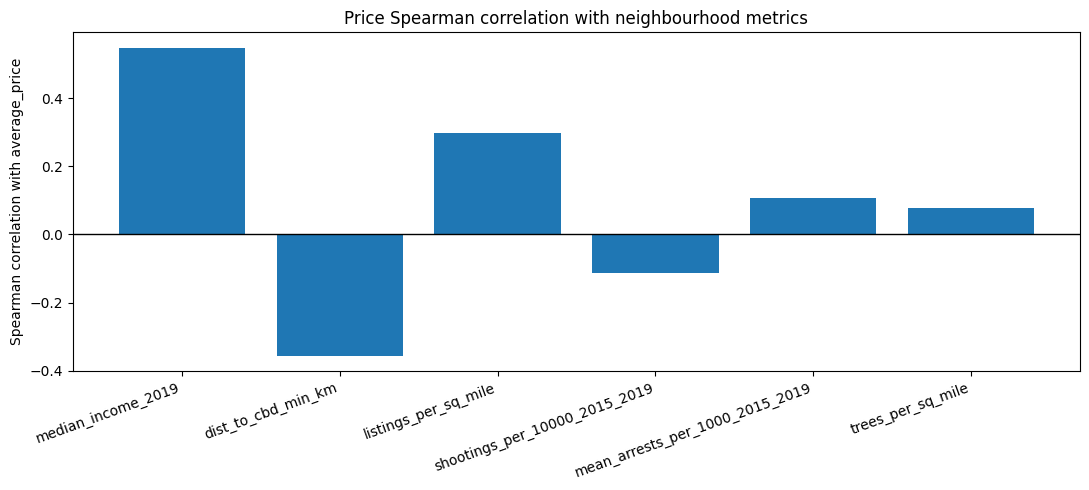

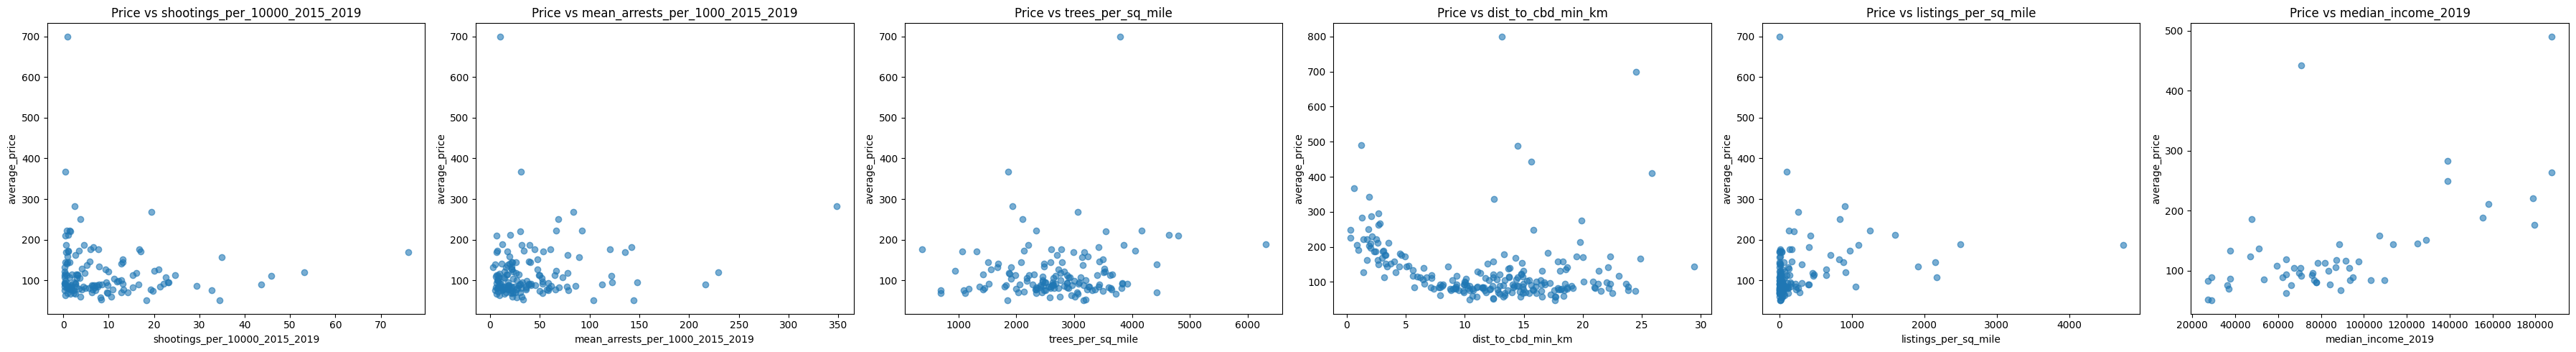

In [48]:
# Combined correlation view: listing-level + neighbourhood-level
 # 1) Listing-level: price vs distance to CBD
listing_level_df = airbnb_nyc_df[['price', 'dist_to_cbd_min_km']].copy()
listing_level_df['price'] = pd.to_numeric(listing_level_df['price'], errors='coerce')
listing_level_df['dist_to_cbd_min_km'] = pd.to_numeric(listing_level_df['dist_to_cbd_min_km'], errors='coerce')
before = len(listing_level_df)
listing_level_df = listing_level_df.dropna(subset=['price', 'dist_to_cbd_min_km']).copy()
print(f'Dropped {before - len(listing_level_df)} rows with missing price or CBD distance ({len(listing_level_df)} rows remaining)')

listing_cbd_corr_summary = pd.DataFrame([
    {
        'variable': 'dist_to_cbd_min_km (listing-level)',
        'spearman_corr_with_price': listing_level_df['price'].corr(listing_level_df['dist_to_cbd_min_km'], method='spearman'),
        'rows_used': len(listing_level_df),
    }
])

print('Listing-level Spearman correlation: price vs dist_to_cbd_min_km')
display(listing_cbd_corr_summary)

# 2) Neighbourhood-level: raw average price vs neighbourhood metrics
# Add listing density: listings_per_sq_mile.
listing_density_df = (
    airbnb_nyc_df[['neighbourhood']]
    .dropna(subset=['neighbourhood'])
    .copy()
)
listing_density_df = (
    listing_density_df
    .groupby('neighbourhood', as_index=False)
    .size()
    .rename(columns={'size': 'listing_count'})
)

listing_density_df = listing_density_df.merge(
    neighborhood_area_df[['neighbourhood', 'area_sq_miles']],
    on='neighbourhood',
    how='inner',
)
listing_density_df = listing_density_df[listing_density_df['area_sq_miles'] > 0].copy()
listing_density_df['listings_per_sq_mile'] = (
    listing_density_df['listing_count'] / listing_density_df['area_sq_miles']
)

corr_source = neighbourhood_combined_metrics.merge(
    cbd_distance_by_neighbourhood,
    on='neighbourhood',
    how='left',
).merge(
    listing_density_df[['neighbourhood', 'listings_per_sq_mile']],
    on='neighbourhood',
    how='left',
).merge(
    median_income_by_neighbourhood,
    on='neighbourhood',
    how='left',
)

corr_cols = [
    'average_price',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]

corr_df = corr_source[corr_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')

# Spearman correlations with average price
target = 'average_price'
feature_cols = [c for c in corr_cols if c != target]

def spearman_with_p(x, y):
    mask = x.notna() & y.notna()
    r, p = stats.spearmanr(x[mask], y[mask])
    return r, p

_spearman_results = {c: spearman_with_p(corr_df[target], corr_df[c]) for c in feature_cols}
corr_summary = pd.DataFrame([
    {
        'variable': c,
        'spearman_corr_with_price': _spearman_results[c][0],
        'p_value': _spearman_results[c][1],
    }
    for c in feature_cols
])

corr_summary = corr_summary.sort_values('spearman_corr_with_price', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print('Spearman correlation with average_price (neighbourhood level):')
display(corr_summary)

# Bar chart of Spearman correlations
plt.figure(figsize=(11, 5))
plt.bar(corr_summary['variable'], corr_summary['spearman_corr_with_price'])
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Spearman correlation with average_price')
plt.title('Price Spearman correlation with neighbourhood metrics')
plt.tight_layout()
plt.show()

# Scatter plots for each variable against price
fig, axes = plt.subplots(1, len(feature_cols), figsize=(36, 5))
if len(feature_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, feature_cols):
    plot_df = corr_df[[target, col]].dropna()
    ax.scatter(plot_df[col], plot_df[target], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'Price vs {col}')

plt.tight_layout()
plt.show()

Interpretation: The Spearman outputs indicate that neighbourhood income and CBD access are among the strongest monotonic associations with Airbnb price, while safety and density variables provide additional explanatory signal. Since Spearman is rank-based, these results support directional relationships even when effects are non-linear.

### Spearman correlation heatmap

To complement the pairwise correlation bars, we visualize the full Spearman correlation matrix across price and all neighbourhood-level predictors.

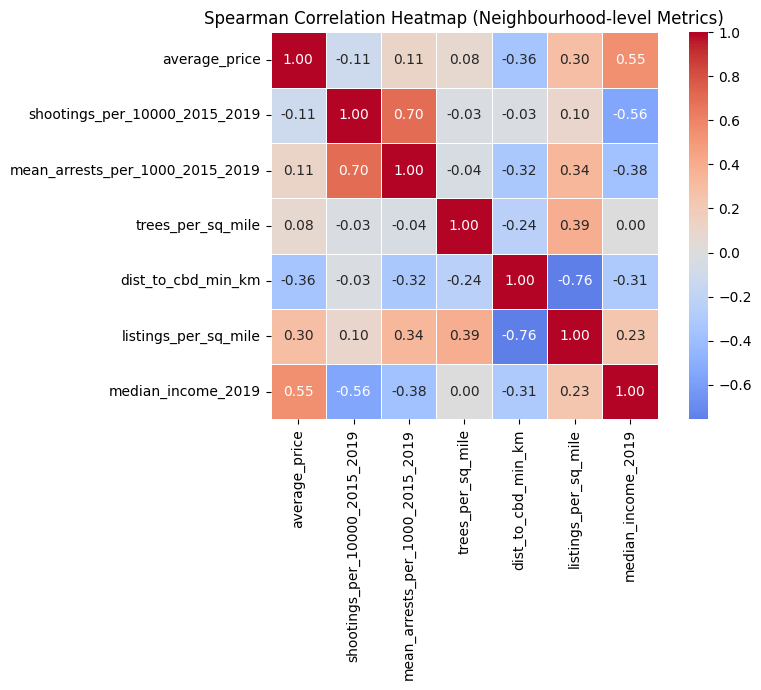

In [49]:
# Spearman heatmap for average price and neighbourhood-level predictors
import seaborn as sns

spearman_matrix = corr_df.corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Spearman Correlation Heatmap (Neighbourhood-level Metrics)')
plt.tight_layout()
plt.show()

Interpretation: The heatmap summarizes the full dependence structure and helps diagnose predictor overlap (multicollinearity). Strong correlation between predictors can cause linear-model impact to be shared across variables, which is one reason rankings may differ from tree-based models.

### Stepwise R-squared drop test

To quantify feature impact in a unit-consistent way, we fit a full linear model on all neighbourhood-level predictors, then remove one feature at a time and measure the R-squared drop.

Full model R-squared: 0.6843
Full model Adjusted R-squared: 0.6381
Most impactful factor by R-squared drop: median_income_2019


,feature_removed,full_r2,reduced_r2,r2_drop,full_adjusted_r2,reduced_adjusted_r2,r2_drop_rank
0,median_income_2019,0.684332,0.484216,0.200116,0.638137,0.422813,1
1,mean_arrests_per_1000_2015_2019,0.684332,0.598796,0.085536,0.638137,0.551033,2
2,listings_per_sq_mile,0.684332,0.636666,0.047666,0.638137,0.593412,3
3,shootings_per_10000_2015_2019,0.684332,0.649092,0.035240,0.638137,0.607317,4
4,dist_to_cbd_min_km,0.684332,0.674492,0.009841,0.638137,0.635741,5
5,trees_per_sq_mile,0.684332,0.677918,0.006414,0.638137,0.639575,6


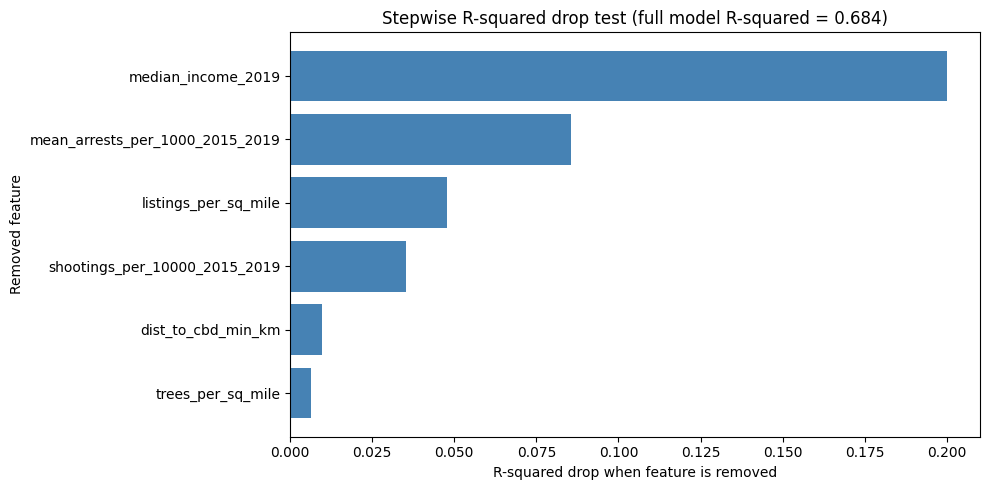

In [50]:
from sklearn.linear_model import LinearRegression

# Build modelling table from the neighbourhood-level analysis columns
model_features = [
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]
model_target = 'average_price'

r2_data = corr_source[[model_target] + model_features].copy()
r2_data = r2_data.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

X_full = r2_data[model_features]
y_full = r2_data[model_target]

base_lr = LinearRegression()
base_lr.fit(X_full, y_full)
base_r2 = base_lr.score(X_full, y_full)


def adjusted_r2(r2_value, n_obs, n_features):
    if n_obs <= n_features + 1:
        return np.nan
    return 1 - (1 - r2_value) * (n_obs - 1) / (n_obs - n_features - 1)


base_adj_r2 = adjusted_r2(base_r2, len(r2_data), X_full.shape[1])

stepwise_rows = []
for feature in model_features:
    reduced_features = [f for f in model_features if f != feature]
    reduced_lr = LinearRegression()
    reduced_lr.fit(r2_data[reduced_features], y_full)
    reduced_r2 = reduced_lr.score(r2_data[reduced_features], y_full)
    reduced_adj_r2 = adjusted_r2(reduced_r2, len(r2_data), len(reduced_features))

    stepwise_rows.append({
        'feature_removed': feature,
        'full_r2': base_r2,
        'reduced_r2': reduced_r2,
        'r2_drop': base_r2 - reduced_r2,
        'full_adjusted_r2': base_adj_r2,
        'reduced_adjusted_r2': reduced_adj_r2,
    })

r2_drop_df = pd.DataFrame(stepwise_rows).sort_values('r2_drop', ascending=False).reset_index(drop=True)
r2_drop_df['r2_drop_rank'] = np.arange(1, len(r2_drop_df) + 1)

print(f'Full model R-squared: {base_r2:.4f}')
print(f'Full model Adjusted R-squared: {base_adj_r2:.4f}')
print('Most impactful factor by R-squared drop:', r2_drop_df.loc[0, 'feature_removed'])
display(r2_drop_df)

plt.figure(figsize=(10, 5))
plt.barh(r2_drop_df['feature_removed'], r2_drop_df['r2_drop'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('R-squared drop when feature is removed')
plt.ylabel('Removed feature')
plt.title(f'Stepwise R-squared drop test (full model R-squared = {base_r2:.3f})')
plt.tight_layout()
plt.show()

Interpretation: The stepwise R-squared drop isolates each feature's marginal contribution within the linear model, identifying the variable whose removal most reduces explanatory power. This is more unit-consistent than directly comparing raw regression coefficients across differently scaled predictors.

### Machine learning validation (default models)

We validate the linear-model impact ranking with three regression models using default hyperparameters: Decision Tree, Random Forest, and XGBoost.

In [51]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

X_ml = r2_data[model_features].copy()
y_ml = r2_data[model_target].copy()

dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42)

dt_model.fit(X_ml, y_ml)
rf_model.fit(X_ml, y_ml)
xgb_model.fit(X_ml, y_ml)

ml_importance_df = pd.DataFrame({
    'feature': model_features,
    'decision_tree_importance': dt_model.feature_importances_,
    'random_forest_importance': rf_model.feature_importances_,
    'xgboost_importance': xgb_model.feature_importances_,
})

print('Feature importances from default ML regressors:')
display(ml_importance_df.sort_values('random_forest_importance', ascending=False).reset_index(drop=True))

Feature importances from default ML regressors:


,feature,decision_tree_importance,random_forest_importance,xgboost_importance
0,dist_to_cbd_min_km,0.728724,0.638026,0.733177
1,median_income_2019,0.053710,0.205576,0.139099
2,mean_arrests_per_1000_2015_2019,0.108061,0.045603,0.021190
3,listings_per_sq_mile,0.061143,0.042590,0.044803
4,shootings_per_10000_2015_2019,0.030447,0.042028,0.048380
5,trees_per_sq_mile,0.017914,0.026176,0.013349


Interpretation: Default Decision Tree, Random Forest, and XGBoost importances provide a model-based robustness check on the linear findings. Because these models are not tuned, importance magnitudes should be treated as directional evidence; tuning depth/regularization can change the relative ranking.

### ML vs R-squared-drop comparison

We compare feature rankings across the stepwise R-squared-drop method and all ML models to check for consensus and method-specific differences.

Feature ranking comparison (R-squared drop vs ML importances):


,feature,decision_tree_importance,random_forest_importance,xgboost_importance,r2_drop,r2_drop_rank,decision_tree_rank,random_forest_rank,xgboost_rank,avg_rank
0,dist_to_cbd_min_km,0.728724,0.638026,0.733177,0.009841,5,1,1,1,2.00
1,median_income_2019,0.053710,0.205576,0.139099,0.200116,1,4,2,2,2.25
2,mean_arrests_per_1000_2015_2019,0.108061,0.045603,0.021190,0.085536,2,2,3,5,3.00
3,listings_per_sq_mile,0.061143,0.042590,0.044803,0.047666,3,3,4,4,3.50
4,shootings_per_10000_2015_2019,0.030447,0.042028,0.048380,0.035240,4,5,5,3,4.25
5,trees_per_sq_mile,0.017914,0.026176,0.013349,0.006414,6,6,6,6,6.00


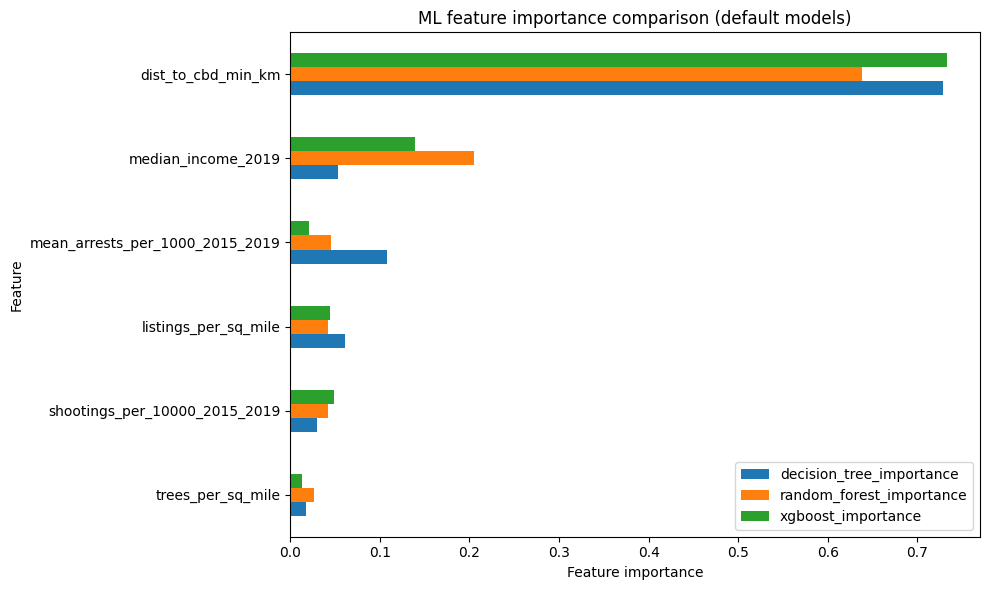

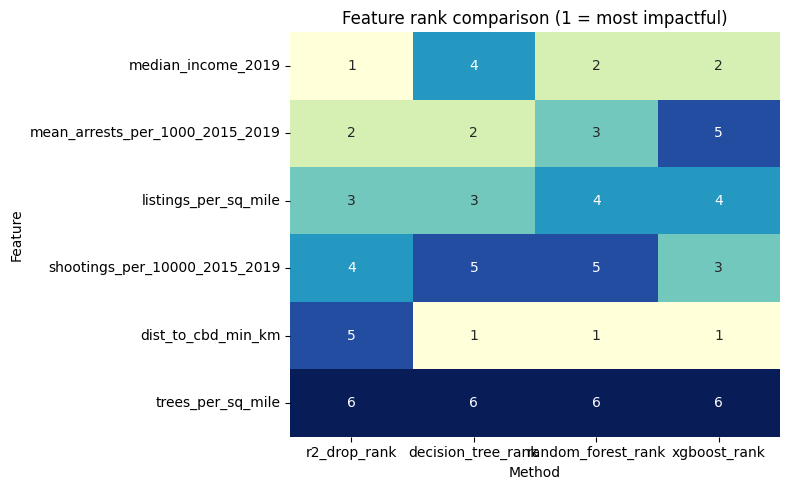

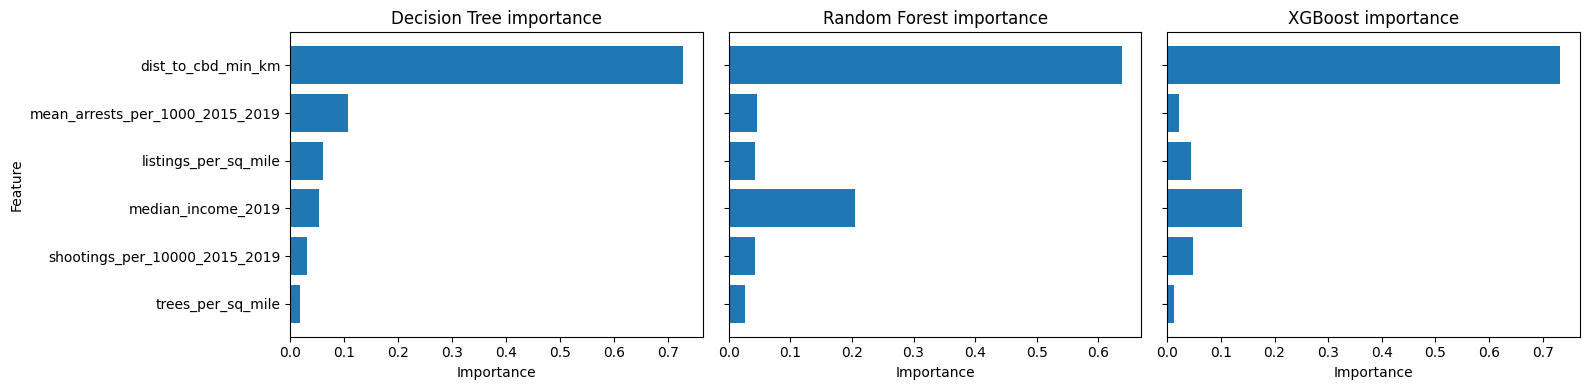

Consensus top feature (lowest average rank): dist_to_cbd_min_km


In [52]:
# Merge stepwise R-squared ranking with ML feature importances
r2_rank_view = r2_drop_df[['feature_removed', 'r2_drop', 'r2_drop_rank']].rename(columns={'feature_removed': 'feature'})

comparison_df = ml_importance_df.merge(r2_rank_view, on='feature', how='left')
comparison_df = comparison_df.sort_values('random_forest_importance', ascending=False).reset_index(drop=True)

comparison_df['decision_tree_rank'] = comparison_df['decision_tree_importance'].rank(ascending=False, method='min').astype(int)
comparison_df['random_forest_rank'] = comparison_df['random_forest_importance'].rank(ascending=False, method='min').astype(int)
comparison_df['xgboost_rank'] = comparison_df['xgboost_importance'].rank(ascending=False, method='min').astype(int)
comparison_df['avg_rank'] = comparison_df[[
    'r2_drop_rank', 'decision_tree_rank', 'random_forest_rank', 'xgboost_rank'
]].mean(axis=1)

print('Feature ranking comparison (R-squared drop vs ML importances):')
display(comparison_df)

# Grouped horizontal bar chart of ML feature importances
plot_df = comparison_df.set_index('feature')[[
    'decision_tree_importance',
    'random_forest_importance',
    'xgboost_importance',
]].sort_values('random_forest_importance', ascending=True)

plot_df.plot(kind='barh', figsize=(10, 6))
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title('ML feature importance comparison (default models)')
plt.tight_layout()
plt.show()

# Rank heatmap for cross-method comparison
rank_heatmap_df = comparison_df.set_index('feature')[[
    'r2_drop_rank',
    'decision_tree_rank',
    'random_forest_rank',
    'xgboost_rank'
]].sort_values('r2_drop_rank')

plt.figure(figsize=(8, 5))
sns.heatmap(rank_heatmap_df, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Feature rank comparison (1 = most impactful)')
plt.xlabel('Method')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Individual importance charts (appendix-style detail)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, col, title in [
    (axes[0], 'decision_tree_importance', 'Decision Tree'),
    (axes[1], 'random_forest_importance', 'Random Forest'),
    (axes[2], 'xgboost_importance', 'XGBoost'),
]:
    model_view = comparison_df[['feature', col]].sort_values(col, ascending=True)
    ax.barh(model_view['feature'], model_view[col])
    ax.set_title(f'{title} importance')
    ax.set_xlabel('Importance')

axes[0].set_ylabel('Feature')
plt.tight_layout()
plt.show()

consensus_top_feature = comparison_df.sort_values('avg_rank', ascending=True).iloc[0]['feature']
print('Consensus top feature (lowest average rank):', consensus_top_feature)

Interpretation: The cross-method rank table and plots compare linear-model impact (R-squared drop) with tree-based feature importance. If rankings differ, that is expected and usually indicates non-linearity, interaction effects, or shared variance among predictors rather than a contradiction.

### Interaction variables (exploratory)

We test whether combined effects (interaction terms) improve explanatory power beyond the additive linear model.

In [53]:
interaction_df = r2_data.copy()
interaction_df['income_x_cbd'] = interaction_df['median_income_2019'] * interaction_df['dist_to_cbd_min_km']
interaction_df['income_x_shootings'] = interaction_df['median_income_2019'] * interaction_df['shootings_per_10000_2015_2019']
interaction_df['income_x_arrests'] = interaction_df['median_income_2019'] * interaction_df['mean_arrests_per_1000_2015_2019']

interaction_features = model_features + [
    'income_x_cbd',
    'income_x_shootings',
    'income_x_arrests',
]

interaction_lr = LinearRegression()
interaction_lr.fit(interaction_df[interaction_features], interaction_df[model_target])
interaction_r2 = interaction_lr.score(interaction_df[interaction_features], interaction_df[model_target])
interaction_adj_r2 = adjusted_r2(interaction_r2, len(interaction_df), len(interaction_features))

r2_gain = interaction_r2 - base_r2

print(f'Base additive model R-squared: {base_r2:.4f}')
print(f'Interaction model R-squared: {interaction_r2:.4f}')
print(f'R-squared gain from interactions: {r2_gain:.4f}')
print(f'Interaction model Adjusted R-squared: {interaction_adj_r2:.4f}')

interaction_coef_df = pd.DataFrame({
    'feature': interaction_features,
    'coefficient': interaction_lr.coef_,
}).sort_values('coefficient', key=lambda x: np.abs(x), ascending=False)

print('Largest interaction coefficients (directional):')
display(interaction_coef_df.head(8))

Base additive model R-squared: 0.6843
Interaction model R-squared: 0.7163
R-squared gain from interactions: 0.0320
Interaction model Adjusted R-squared: 0.6492
Largest interaction coefficients (directional):


,feature,coefficient
0,shootings_per_10000_2015_2019,1.246935
3,dist_to_cbd_min_km,1.035963
1,mean_arrests_per_1000_2015_2019,-0.094719
4,listings_per_sq_mile,0.026347
2,trees_per_sq_mile,-0.005790
5,median_income_2019,0.000894
7,income_x_shootings,-0.000029
6,income_x_cbd,-0.000018


Interpretation note: interaction terms test whether the relationship between one factor (for example CBD distance) changes across another context variable (for example income). If linear-model rankings and ML rankings differ, this is not a contradiction; ML models can capture non-linear splits and interactions that simple additive linear models do not represent.

### Linear-model residual diagnostics

Residual diagnostics help us assess whether a linear form is a reasonable approximation for this explanatory analysis.

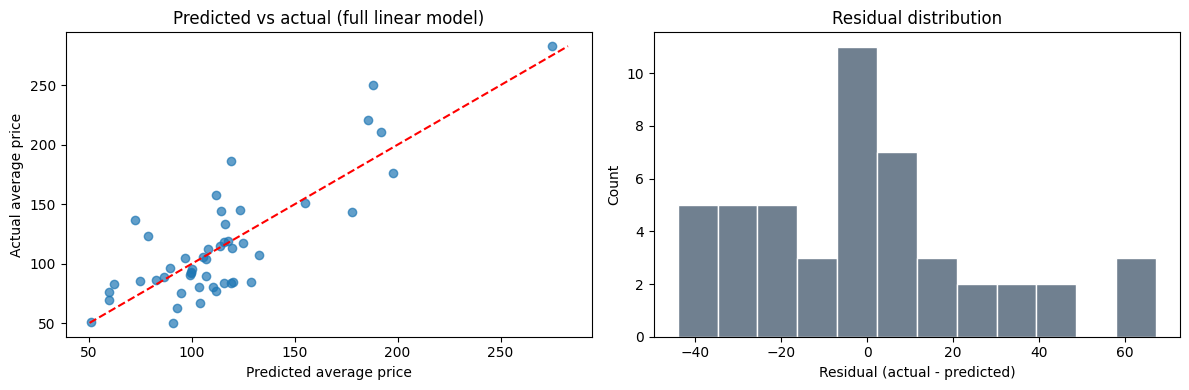

In [54]:
y_pred_full = base_lr.predict(X_full)
residuals_full = y_full - y_pred_full

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_full, y_full, alpha=0.7)
min_val = min(y_full.min(), y_pred_full.min())
max_val = max(y_full.max(), y_pred_full.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red')
axes[0].set_xlabel('Predicted average price')
axes[0].set_ylabel('Actual average price')
axes[0].set_title('Predicted vs actual (full linear model)')

axes[1].hist(residuals_full, bins=12, color='slategray', edgecolor='white')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

Interpretation: Residual diagnostics assess how well a linear model captures the observed price pattern. Any visible curvature, fan shape, or heavy-tailed residual spread suggests that some relationships are non-linear or that additional predictors/interactions are still missing.

### Choropleth maps: spatial distribution of outcomes

These maps visualize neighbourhood-level average Airbnb price and the top factor identified by the stepwise R-squared-drop test.

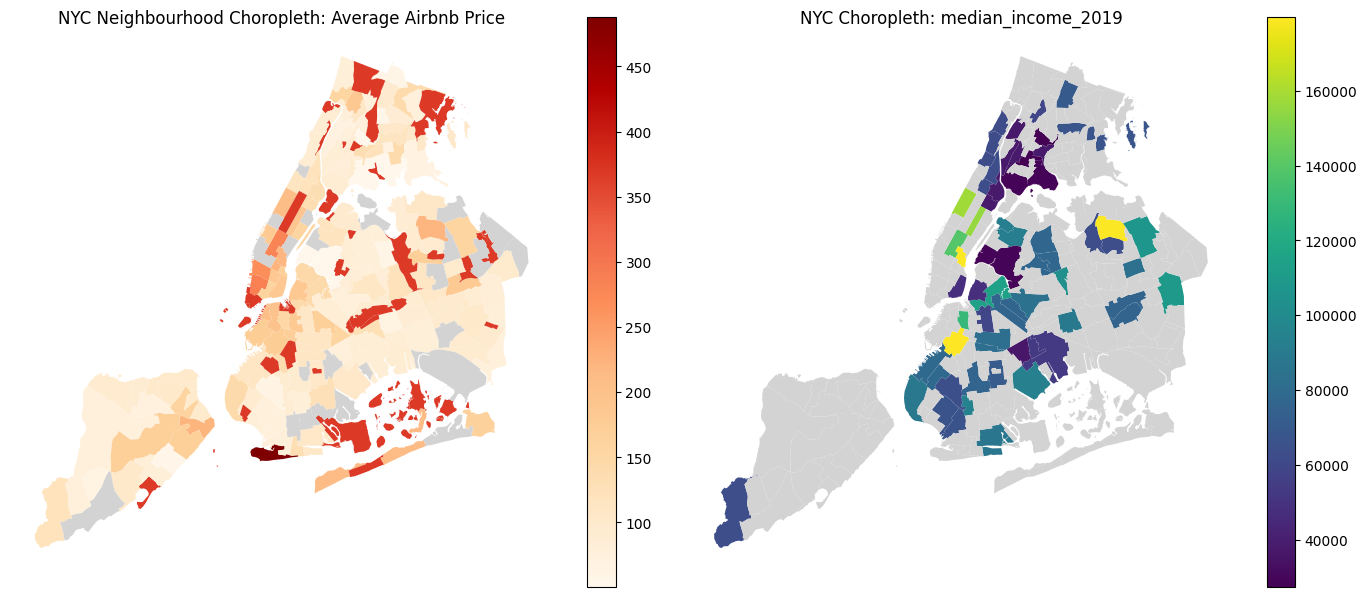

In [64]:
map_df = corr_source[['neighbourhood', 'average_price'] + model_features].copy()
map_df = map_df.apply(lambda col: pd.to_numeric(col, errors='coerce') if col.name != 'neighbourhood' else col)

nyc_map = nyc_gdf.copy()

# Robustly detect the neighbourhood name column from nycgeo variants.
name_col = None
for c in nyc_map.columns:
    cl = str(c).lower().replace('_', '').replace(' ', '')
    if 'nta' in cl and 'name' in cl:
        name_col = c
        break

if name_col is None:
    for fallback in ['neighbourhood', 'neighborhood', 'name']:
        if fallback in nyc_map.columns:
            name_col = fallback
            break

if name_col is None:
    raise KeyError(
        f"Could not find neighbourhood name column in nyc_gdf. Available columns: {list(nyc_map.columns)}"
    )

nyc_map['geo_neighbourhood_raw'] = nyc_map[name_col].astype(str)
nyc_map['geo_neighbourhood_clean'] = nyc_map['geo_neighbourhood_raw'].map(clean_neighbourhood_keep_coop)

neighbourhood_lookup = map_df['neighbourhood'].dropna().astype(str).unique().tolist()

def fuzzy_match_single_name(name, choices, threshold=75):
    if pd.isna(name):
        return None
    name = str(name).strip()
    if not name:
        return None
    best = process.extractOne(name, choices)
    if best is None:
        return None
    match, score = best
    return match if score >= threshold else None

nyc_map['neighbourhood'] = nyc_map['geo_neighbourhood_clean'].map(
    lambda x: fuzzy_match_single_name(x, neighbourhood_lookup)
)

map_join = nyc_map.merge(map_df, on='neighbourhood', how='left')

top_r2_feature = r2_drop_df.loc[0, 'feature_removed']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

map_join.plot(
    column='average_price',
    cmap='OrRd',
    legend=True,
    ax=axes[0],
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
axes[0].set_title('NYC Neighbourhood Choropleth: Average Airbnb Price')
axes[0].axis('off')

map_join.plot(
    column=top_r2_feature,
    cmap='viridis',
    legend=True,
    ax=axes[1],
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
axes[1].set_title(f'NYC Choropleth: {top_r2_feature}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Interpretation: The choropleths show clear spatial clustering of both average Airbnb prices and the top explanatory factor, indicating that pricing patterns follow neighbourhood geography rather than random variation. Because fuzzy name matching is used to join polygons to Airbnb neighbourhood labels, small boundary/name mismatches may remain but the broad spatial signal is still informative.

Pair plot and room-type distribution

These plots provide supplementary evidence on multivariate relationships and within-market price dispersion by room type.

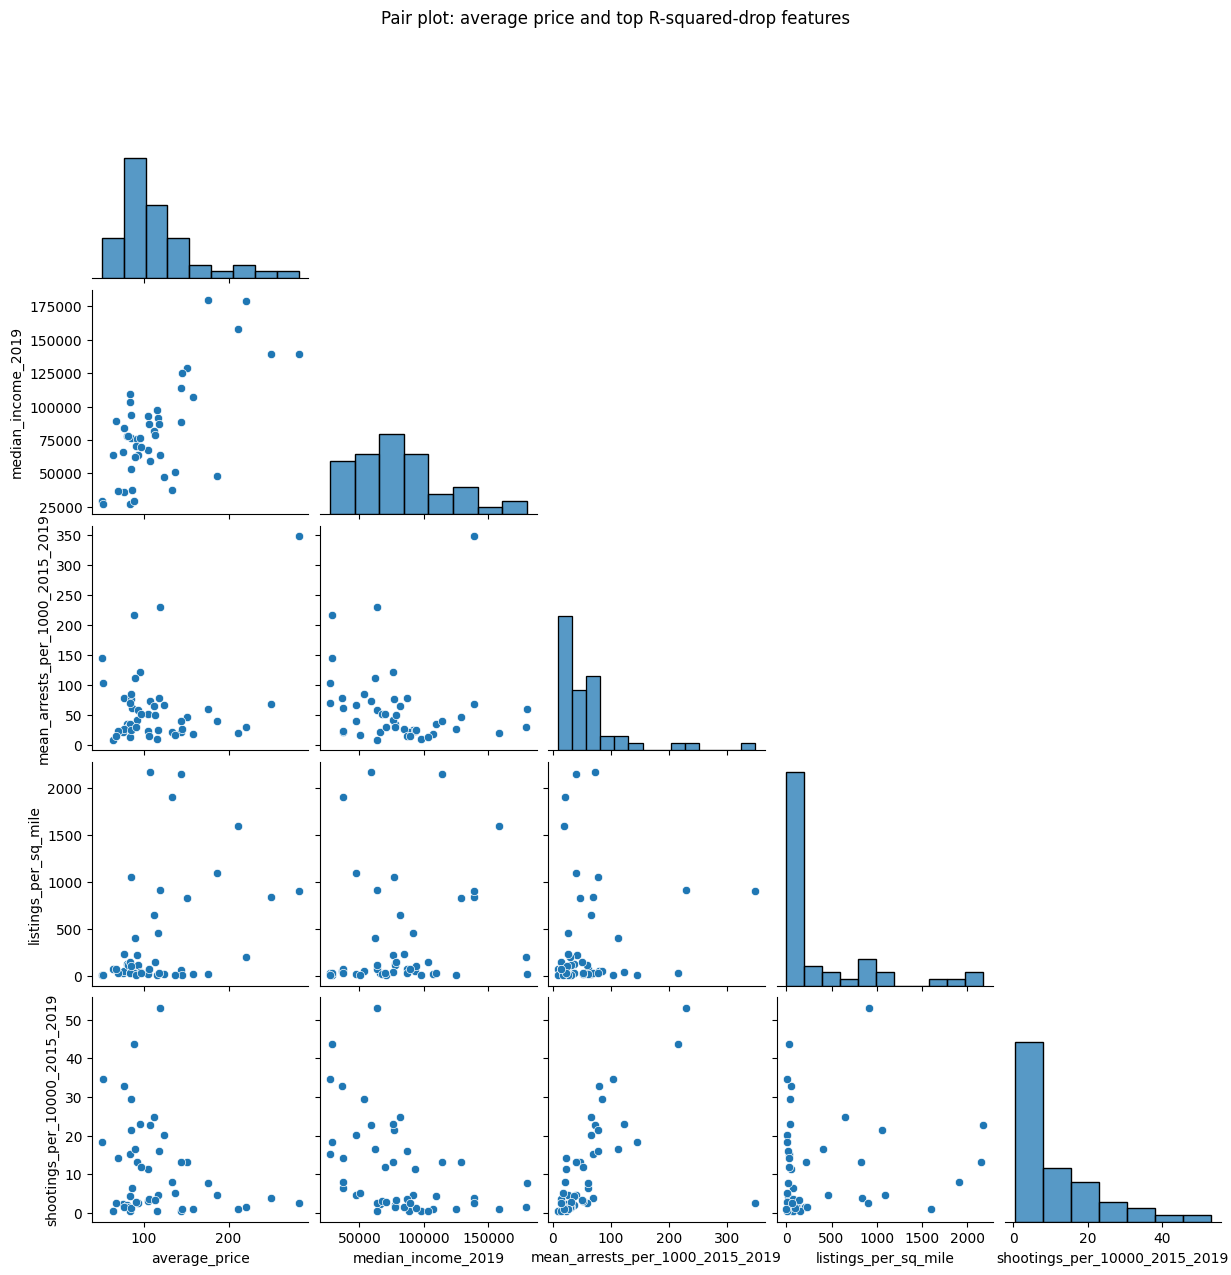

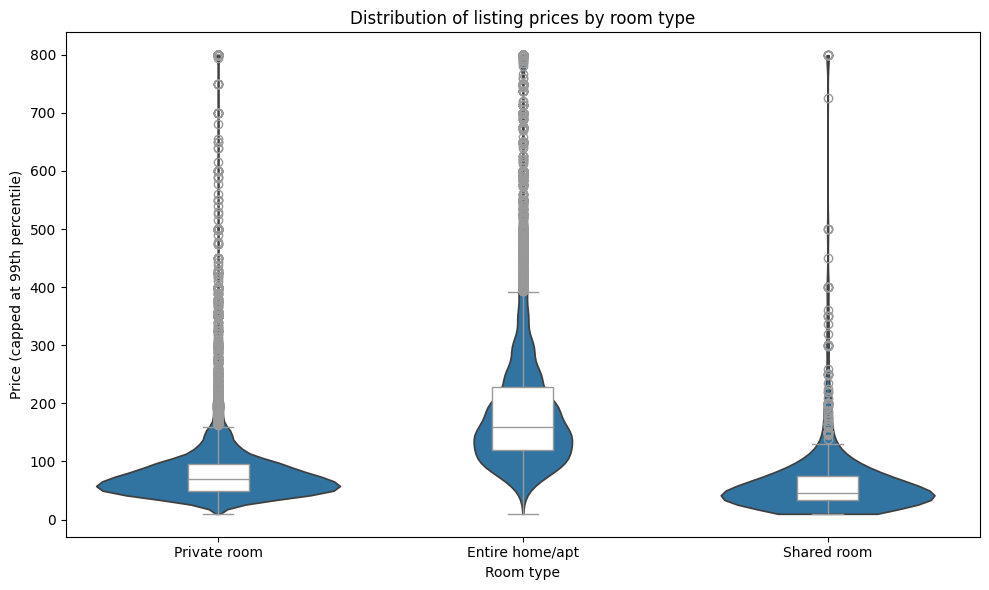

In [58]:
# Pair plot for top features from R-squared-drop ranking
top_features_for_pairplot = r2_drop_df['feature_removed'].head(4).tolist()
pairplot_df = r2_data[[model_target] + top_features_for_pairplot].dropna().copy()

sns.pairplot(pairplot_df, corner=True, diag_kind='hist')
plt.suptitle('Pair plot: average price and top R-squared-drop features', y=1.02)
plt.show()

# Violin + box plot for listing-level price by room type
room_price_df = airbnb_nyc_df[['room_type', 'price']].copy()
room_price_df['price'] = pd.to_numeric(room_price_df['price'], errors='coerce')
room_price_df = room_price_df.dropna()
room_price_df = room_price_df[room_price_df['price'] > 0]
room_price_df['price_capped'] = room_price_df['price'].clip(upper=room_price_df['price'].quantile(0.99))

plt.figure(figsize=(10, 6))
sns.violinplot(data=room_price_df, x='room_type', y='price_capped', inner=None, cut=0)
sns.boxplot(data=room_price_df, x='room_type', y='price_capped', width=0.2, color='white')
plt.xlabel('Room type')
plt.ylabel('Price (capped at 99th percentile)')
plt.title('Distribution of listing prices by room type')
plt.tight_layout()
plt.show()

Interpretation: The pair plot confirms that relationships between price and the top-ranked factors are not perfectly linear, with visible clustering and curvature in several feature pairs. The room-type violin/box plot also shows strong within-market heterogeneity, meaning part of neighbourhood-level price variation may reflect listing composition (for example, more entire-home listings).

### Data coverage check and profiling

Before deeper comparisons, we profile the merged neighbourhood-level analysis table to inspect coverage and missingness for each derived metric.

In [59]:
analysis_cols = [
    'neighbourhood',
    'average_price',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]

analysis_table = corr_source[analysis_cols].copy()

missing_profile = (
    analysis_table
    .isna()
    .sum()
    .to_frame('missing_count')
    .assign(missing_pct=lambda d: (d['missing_count'] / len(analysis_table) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

print('Missing-value profile for integrated neighbourhood analysis table:')
display(missing_profile)

print('Summary statistics for numeric variables used in analysis:')
display(
    analysis_table
    .drop(columns=['neighbourhood'])
    .apply(pd.to_numeric, errors='coerce')
    .describe()
    .T
)

print(f"Total neighbourhood rows in integrated table: {len(analysis_table)}")

Missing-value profile for integrated neighbourhood analysis table:


,missing_count,missing_pct
median_income_2019,165,75.00
shootings_per_10000_2015_2019,84,38.18
trees_per_sq_mile,75,34.09
mean_arrests_per_1000_2015_2019,75,34.09
listings_per_sq_mile,75,34.09
average_price,0,0.00
neighbourhood,0,0.00
dist_to_cbd_min_km,0,0.00


Summary statistics for numeric variables used in analysis:


,count,mean,std,min,25%,50%,75%,max
average_price,220.0,133.343373,94.721695,47.333333,81.598077,101.314474,153.223214,800.000000
shootings_per_10000_2015_2019,136.0,8.713819,11.406169,0.247614,1.333936,4.451915,12.253441,76.013112
mean_arrests_per_1000_2015_2019,145.0,41.509872,46.247478,3.080318,14.507579,26.481238,52.382043,348.250087
trees_per_sq_mile,145.0,2694.707040,872.888126,367.647832,2181.220152,2678.468993,3203.753002,6307.779110
dist_to_cbd_min_km,220.0,11.931923,6.396123,0.329212,7.149671,12.398754,16.441948,29.431199
listings_per_sq_mile,145.0,246.616552,575.933898,0.429131,11.182004,44.546233,160.845287,4740.312929
median_income_2019,55.0,86127.291142,41458.444654,27324.753710,62763.587530,77790.755090,100372.890035,187634.991600


Total neighbourhood rows in integrated table: 220


From this profiling, we can verify whether the integrated table is sufficiently complete for comparative analysis. Variables with higher missingness should be interpreted with caution in downstream conclusions.

### Borough-level comparison

To add interpretive context, we map each neighbourhood to its dominant borough (based on Airbnb listings) and compare borough-level price and feature aggregates.

Borough-level contextual summary (means over mapped neighbourhoods):


,borough,neighbourhoods,avg_price,avg_shootings_per_10000,avg_arrests_per_1000,avg_trees_per_sq_mile,avg_median_income
2,Manhattan,32,212.277558,11.342467,76.996118,3183.595574,123369.860720
4,Staten Island,42,143.908728,5.708164,26.847976,2186.613612,102366.634337
1,Brooklyn,47,137.685040,9.911317,42.798914,2792.647957,82390.650642
3,Queens,51,108.577211,5.357547,27.214519,2654.571581,88860.367977
0,Bronx,48,93.538726,11.750489,47.374646,2684.595120,47000.617932


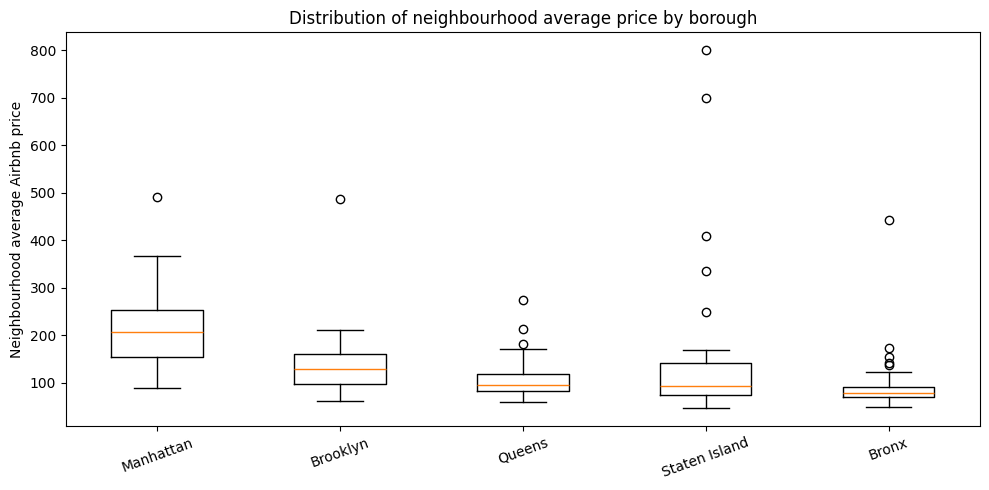

In [60]:
# Build neighbourhood-to-borough lookup using the most frequent borough per neighbourhood.
hood_borough_map = (
    airbnb_nyc_df[['neighbourhood', 'neighbourhood_group']]
    .dropna(subset=['neighbourhood', 'neighbourhood_group'])
    .copy()
)
hood_borough_map['neighbourhood'] = hood_borough_map['neighbourhood'].apply(clean_neighbourhood_keep_coop)
hood_borough_map = (
    hood_borough_map
    .groupby('neighbourhood')['neighbourhood_group']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
    .reset_index()
    .rename(columns={'neighbourhood_group': 'borough'})
)

borough_analysis = analysis_table.merge(hood_borough_map, on='neighbourhood', how='left')

borough_summary = (
    borough_analysis
    .groupby('borough', as_index=False)
    .agg(
        neighbourhoods=('neighbourhood', 'nunique'),
        avg_price=('average_price', 'mean'),
        avg_shootings_per_10000=('shootings_per_10000_2015_2019', 'mean'),
        avg_arrests_per_1000=('mean_arrests_per_1000_2015_2019', 'mean'),
        avg_trees_per_sq_mile=('trees_per_sq_mile', 'mean'),
        avg_median_income=('median_income_2019', 'mean')
    )
    .sort_values('avg_price', ascending=False)
)

print('Borough-level contextual summary (means over mapped neighbourhoods):')
display(borough_summary)

# Price distribution by borough (neighbourhood-level average price).
plot_df = borough_analysis[['borough', 'average_price']].dropna()
borough_order = plot_df.groupby('borough')['average_price'].median().sort_values(ascending=False).index.tolist()
groups = [plot_df.loc[plot_df['borough'] == b, 'average_price'].values for b in borough_order]

plt.figure(figsize=(10, 5))
plt.boxplot(groups, tick_labels=borough_order)
plt.ylabel('Neighbourhood average Airbnb price')
plt.title('Distribution of neighbourhood average price by borough')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Composite neighbourhood signal

Finally, we build a simple composite index by standardizing key indicators and combining favorable (+) and unfavorable (-) signals. This provides an interpretable ranking view to complement pairwise correlations.

Top 10 neighbourhoods by composite signal score:


,neighbourhood,average_price,composite_signal_score
43,Upper West Side,210.918316,1.456505
28,Murray Hill,220.958763,1.327203
18,Fort Greene,151.374233,0.724541
22,Jackson Heights,80.897849,0.588017
9,Chelsea,249.738544,0.575905
32,Rego Park,83.877358,0.573444
33,Ridgewood,77.184397,0.516492
0,Astoria,117.187778,0.475141
1,Bay Ridge,144.432624,0.434021
5,Borough Park,63.066176,0.409739


Bottom 10 neighbourhoods by composite signal score:


,neighbourhood,average_price,composite_signal_score
27,Mott Haven,88.916667,-1.370662
19,Harlem,118.974041,-0.983982
11,Coney Island,123.705882,-0.937529
21,Hunts Point,50.500000,-0.868136
40,Tremont,51.545455,-0.754866
23,Jamaica,95.770563,-0.720702
6,Brownsville,76.459016,-0.658742
14,East New York,85.426606,-0.618472
39,Tottenville,144.857143,-0.469502
45,Williamsbridge,96.750000,-0.347827


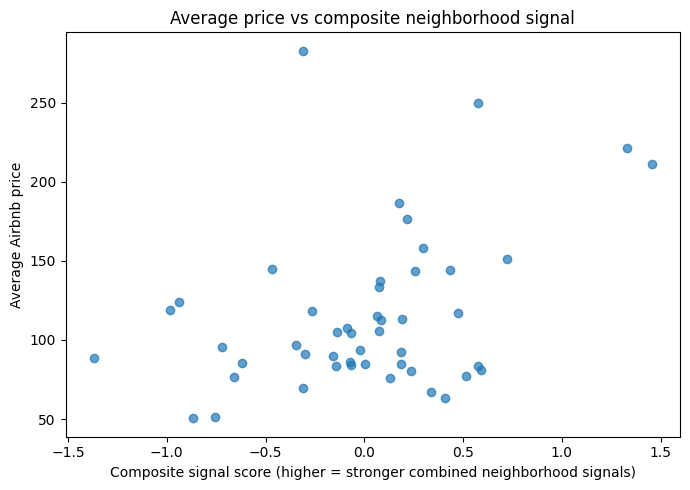

Spearman correlation: average_price vs composite_signal_score
0.23740772904906643


In [61]:
rank_df = analysis_table[[
    'neighbourhood',
    'average_price',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'median_income_2019',
]].copy()

rank_df = rank_df.dropna().reset_index(drop=True)

# Z-score utility with safe handling.
def zscore_series(s):
    s = pd.to_numeric(s, errors='coerce')
    std = s.std(ddof=1)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

rank_df['income_z'] = zscore_series(rank_df['median_income_2019'])
rank_df['greenery_z'] = zscore_series(rank_df['trees_per_sq_mile'])
rank_df['access_z'] = -zscore_series(rank_df['dist_to_cbd_min_km'])
rank_df['safety_shoot_z'] = -zscore_series(rank_df['shootings_per_10000_2015_2019'])
rank_df['safety_arrest_z'] = -zscore_series(rank_df['mean_arrests_per_1000_2015_2019'])

rank_df['composite_signal_score'] = rank_df[
    ['income_z', 'greenery_z', 'access_z', 'safety_shoot_z', 'safety_arrest_z']
].mean(axis=1)

top_signal = rank_df.sort_values('composite_signal_score', ascending=False).head(10)
bottom_signal = rank_df.sort_values('composite_signal_score', ascending=True).head(10)

print('Top 10 neighbourhoods by composite signal score:')
display(top_signal[['neighbourhood', 'average_price', 'composite_signal_score']])

print('Bottom 10 neighbourhoods by composite signal score:')
display(bottom_signal[['neighbourhood', 'average_price', 'composite_signal_score']])

# Relationship between composite signal and average price.
plt.figure(figsize=(7, 5))
plt.scatter(rank_df['composite_signal_score'], rank_df['average_price'], alpha=0.7)
plt.xlabel('Composite signal score (higher = stronger combined neighborhood signals)')
plt.ylabel('Average Airbnb price')
plt.title('Average price vs composite neighborhood signal')
plt.tight_layout()
plt.show()

print('Spearman correlation: average_price vs composite_signal_score')
print(rank_df['average_price'].corr(rank_df['composite_signal_score'], method='spearman'))

### Analytical Summary

Overall, this analysis combines univariate profiling, rank-based correlation, borough context, and a multi-indicator composite view. Together, these outputs provide a coherent basis for discussing which neighbourhood conditions appear most aligned with Airbnb pricing patterns and where potential confounding or missing-data limits remain.

---

# Presentation of main results (Share)

## Key findings

Based on our analysis, the strongest explanatory factors for NYC neighbourhood-level Airbnb prices are identified using two complementary methods: stepwise R-squared drop (linear model) and default-ML feature importances.

- **Most impactful factor (R-squared drop test)**: The variable whose removal causes the largest R-squared decline is interpreted as the strongest explanatory factor under a linear specification.
- **Cross-method validation**: Decision Tree, Random Forest, and XGBoost feature importance rankings broadly validate the main price drivers.
- **Core recurring signals**: CBD access, local income, and safety indicators remain the dominant explanatory dimensions.
- **Method mismatch interpretation**: If top-ranked factors differ between linear and ML models, this is expected because tree-based ML models capture non-linear and interaction effects that linear models may miss.
- **Scope note**: Models are explanatory and run with default hyperparameters; full tuning is outside current module scope.

## Target Audience

This analysis is intended for:
- **New Airbnb hosts** looking to price their listings competitively
- **Urban analysts and policymakers** studying the relationship between neighbourhood conditions and short-term rental markets
- **Academic audiences** exploring data-driven approaches to housing economics

## Final Visualizations

Key charts produced during the Analyze phase include:
- Spearman correlation bar/scatter outputs plus correlation heatmap
- Stepwise R-squared drop bar chart and ranking table
- ML feature-importance comparison (grouped bars, per-model bars, rank heatmap)
- Residual diagnostics (predicted vs actual and residual distribution)
- Choropleth maps for average price and the top R-squared-drop feature
- Pair plot of top-ranked features and room-type price distribution

## Data Visualization & Relationships

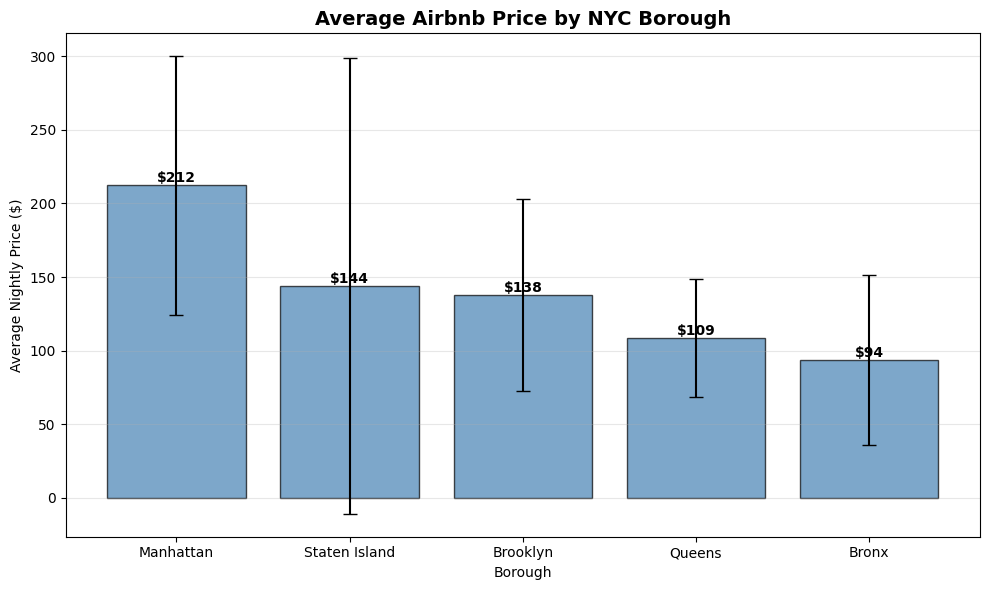

Average prices:          borough        mean         std  count
2      Manhattan  212.277558   87.793348     32
4  Staten Island  143.908728  154.771118     42
1       Brooklyn  137.685040   65.210236     47
3         Queens  108.577211   39.952926     51
0          Bronx   93.538726   57.639359     48


In [62]:
# Distribution of average price by borough
import matplotlib.pyplot as plt

# Use borough_analysis which has the borough column
borough_price = borough_analysis.groupby('borough')['average_price'].agg(['mean', 'std', 'count']).reset_index()
borough_price = borough_price.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(borough_price['borough'], borough_price['mean'], yerr=borough_price['std'], capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_title('Average Airbnb Price by NYC Borough', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Nightly Price ($)')
ax.set_xlabel('Borough')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.0f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Average prices: {borough_price.to_string()}')

C:\Users\chuan\AppData\Local\Temp\ipykernel_51216\1970379060.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_subset, x='borough', y='average_price', ax=axes[1, 1], palette='husl')


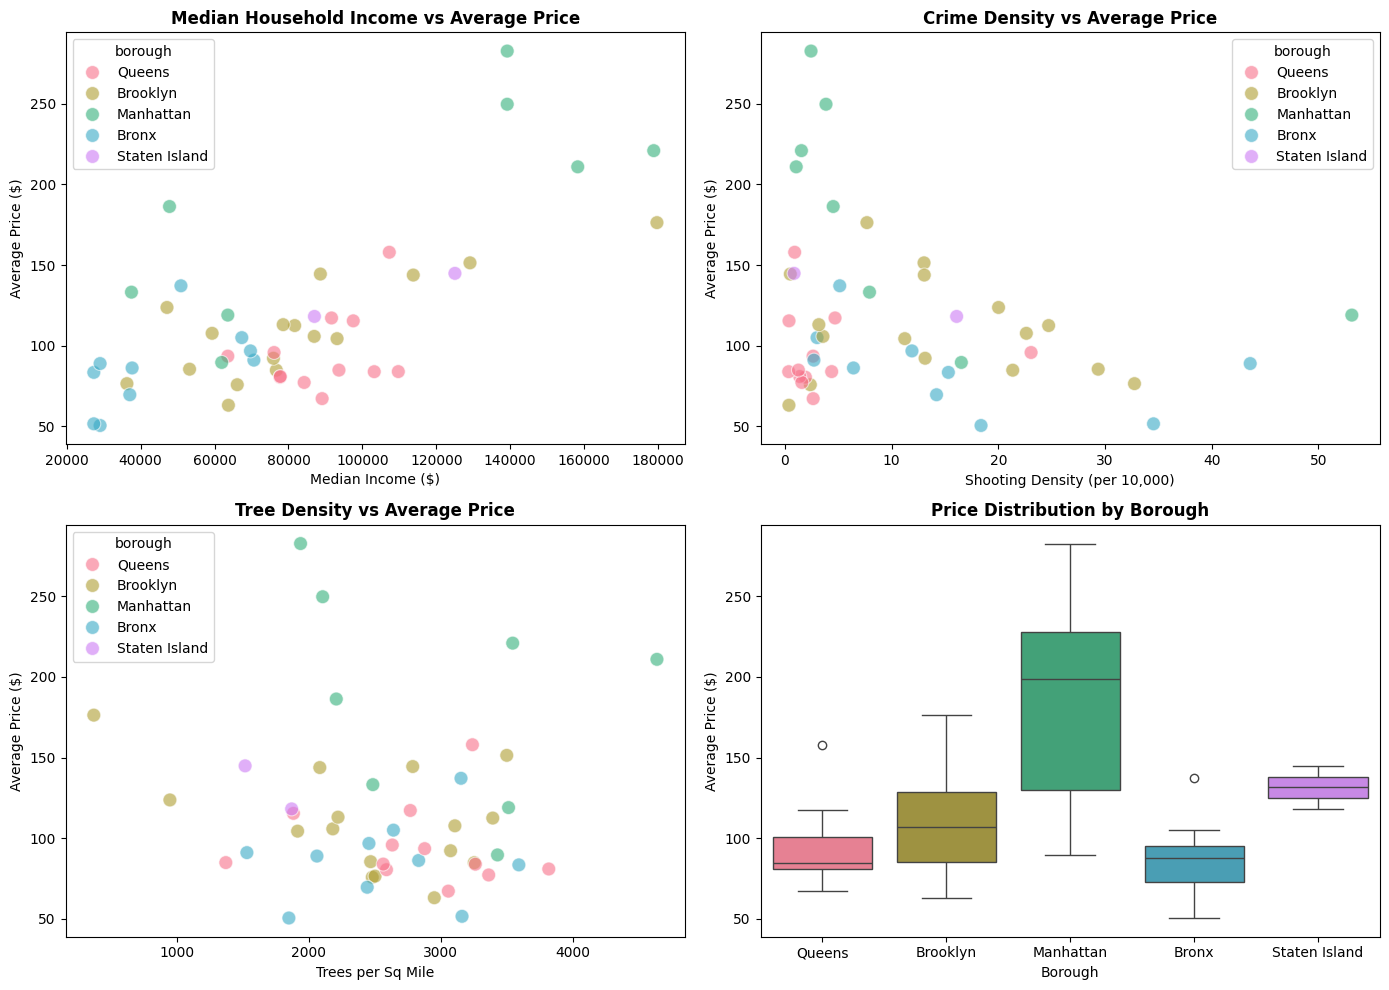

Relationship panel created showing price interactions with key features


In [63]:
# Relationship panel: Key features vs price (by borough)
import seaborn as sns
import matplotlib.pyplot as plt

# Use borough_analysis which has the borough column
analysis_subset = borough_analysis[[
    'neighbourhood',
    'borough',
    'average_price',
    'median_income_2019',
    'shootings_per_10000_2015_2019',
    'trees_per_sq_mile'
]].dropna()

# Create figure with subplots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income vs Price
sns.scatterplot(data=analysis_subset, x='median_income_2019', y='average_price', 
                hue='borough', ax=axes[0, 0], s=100, alpha=0.6, palette='husl')
axes[0, 0].set_title('Median Household Income vs Average Price', fontweight='bold')
axes[0, 0].set_xlabel('Median Income ($)')
axes[0, 0].set_ylabel('Average Price ($)')

# Crime vs Price
sns.scatterplot(data=analysis_subset, x='shootings_per_10000_2015_2019', y='average_price',
                hue='borough', ax=axes[0, 1], s=100, alpha=0.6, palette='husl')
axes[0, 1].set_title('Crime Density vs Average Price', fontweight='bold')
axes[0, 1].set_xlabel('Shooting Density (per 10,000)')
axes[0, 1].set_ylabel('Average Price ($)')

# Trees vs Price
sns.scatterplot(data=analysis_subset, x='trees_per_sq_mile', y='average_price',
                hue='borough', ax=axes[1, 0], s=100, alpha=0.6, palette='husl')
axes[1, 0].set_title('Tree Density vs Average Price', fontweight='bold')
axes[1, 0].set_xlabel('Trees per Sq Mile')
axes[1, 0].set_ylabel('Average Price ($)')

# Price distribution by borough
sns.boxplot(data=analysis_subset, x='borough', y='average_price', ax=axes[1, 1], palette='husl')
axes[1, 1].set_title('Price Distribution by Borough', fontweight='bold')
axes[1, 1].set_xlabel('Borough')
axes[1, 1].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

print('Relationship panel created showing price interactions with key features')

---

# Possible actions based on results (Act)

## Recommendations

Based on the findings, the following actionable recommendations are proposed:

1. **Pricing by location**: New hosts should benchmark against neighbourhood-level median prices and factor in their distance to Manhattan's CBD when setting initial listing prices.
2. **Safety as a differentiator**: Hosts in high-arrest / high-shooting-density neighbourhoods may need to offer more competitively low prices or invest in listing quality signals (professional photography, detailed descriptions) to offset the perceived neighbourhood risk premium.
3. **Greenery & livability**: Listings near large parks or tree-lined streets could market this as a premium feature, given the modest positive price signal.
4. **Income segmentation**: Platforms and analysts should segment NYC into income tiers when building pricing models, as median income is one of the most consistent predictors of neighbourhood-level price floors.

## Next Steps

- Extend the same R-squared-drop and ML-importance framework to time-series slices (for example 2020-2023) to test whether factor importance remains stable over time.
- Expand geographical resolution from neighbourhood-level aggregates to finer NTA-level boundaries for more localized interpretation.
- Add sentiment-derived review features and re-check whether explanatory rankings shift when quality perception is explicitly modeled.
- Compare default models against tuned versions in future work; in this project, default hyperparameters are intentionally used because tuning is outside current module scope.–2023) to test whether factor importance remains stable over time.
- Expand geographical resolution from neighbourhood-level aggregates to finer NTA-level boundaries for more localized interpretation.
- Add sentiment-derived review features and re-check whether explanatory rankings shift when quality perception is explicitly modeled.
- Compare default models against tuned versions in future work; in this project, default hyperparameters are intentionally used because tuning is outside current module scope.

---

# Final Reflection

- **Temporal mismatch**: The Airbnb dataset is from 2019, the tree census from 2015, and arrest/shooting data spans 2006â€“2019. Features derived from different years may introduce temporal inconsistencies.
- **Reporting bias**: Crime datasets only capture reported incidents; under-reporting in certain neighbourhoods may distort safety metrics.
- **Fuzzy matching errors**: Neighbourhood name harmonization via fuzzy matching introduces a small risk of incorrect linkages, particularly for ambiguously named areas.
- **Omitted variables**: Factors such as transit access, school quality, tourism proximity, and Airbnb amenities are not captured in this dataset and may confound results.
- **Correlation â‰  Causation**: All relationships identified are correlational; causal claims require experimental or quasi-experimental designs.

## Ethical Considerations

- **Neighbourhood stigmatization**: Associating high crime density with lower Airbnb prices could reinforce negative stereotypes about certain communities. Results should be communicated carefully and in broader socioeconomic context.
- **Gentrification risk**: Using Airbnb pricing patterns to guide investment could accelerate gentrification in lower-income neighbourhoods that are currently underpriced.

## Privacy & Security

- All datasets used are publicly available and do not include personally identifiable information (PII) at the individual level.
- Host names and listing IDs in the Airbnb dataset could theoretically be linked to individuals; these columns are not used in any analytical outputs.
- Crime data involves sensitive demographic information; only aggregate borough/neighbourhood counts are used, with no individual-level profiling.